In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv(r"/content/train_FD003.csv")

In [3]:
cols = ['id', 'num_of_cycles','op_setting_1', 'op_setting_2', 'op_setting_3'] + [f'sensor_{i}' for i in range(1, 22)]

df.columns = cols

In [4]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
id               0
num_of_cycles    0
op_setting_1     0
op_setting_2     0
op_setting_3     0
sensor_1         0
sensor_2         0
sensor_3         0
sensor_4         0
sensor_5         0
sensor_6         0
sensor_7         0
sensor_8         0
sensor_9         0
sensor_10        0
sensor_11        0
sensor_12        0
sensor_13        0
sensor_14        0
sensor_15        0
sensor_16        0
sensor_17        0
sensor_18        0
sensor_19        0
sensor_20        0
sensor_21        0
dtype: int64


In [5]:
# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [6]:
df.head()

,id,num_of_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,2,0.0008,-0.0003,100.0,518.67,642.50,1584.69,1396.89,14.62,...,522.42,2388.03,8152.85,8.4403,0.03,392,2388,100.0,38.99,23.4491
1,1,3,-0.0014,-0.0002,100.0,518.67,642.18,1582.35,1405.61,14.62,...,522.03,2388.00,8150.17,8.3901,0.03,391,2388,100.0,38.85,23.3669
2,1,4,-0.0020,0.0001,100.0,518.67,642.92,1585.61,1392.27,14.62,...,522.49,2388.08,8146.56,8.3878,0.03,392,2388,100.0,38.96,23.2951
3,1,5,0.0016,0.0000,100.0,518.67,641.68,1588.63,1397.65,14.62,...,522.58,2388.03,8147.80,8.3869,0.03,392,2388,100.0,39.14,23.4583
4,1,6,0.0011,-0.0005,100.0,518.67,642.24,1584.09,1400.01,14.62,...,522.42,2388.02,8144.92,8.4152,0.03,393,2388,100.0,38.92,23.4281


In [7]:
max_cycles = df.groupby('id')['num_of_cycles'].max().reset_index()
max_cycles.columns = ['id', 'max_cycles']

In [8]:
df = df.merge(max_cycles, on='id', how='left')

In [9]:
df.head()

,id,num_of_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycles
0,1,2,0.0008,-0.0003,100.0,518.67,642.50,1584.69,1396.89,14.62,...,2388.03,8152.85,8.4403,0.03,392,2388,100.0,38.99,23.4491,259
1,1,3,-0.0014,-0.0002,100.0,518.67,642.18,1582.35,1405.61,14.62,...,2388.00,8150.17,8.3901,0.03,391,2388,100.0,38.85,23.3669,259
2,1,4,-0.0020,0.0001,100.0,518.67,642.92,1585.61,1392.27,14.62,...,2388.08,8146.56,8.3878,0.03,392,2388,100.0,38.96,23.2951,259
3,1,5,0.0016,0.0000,100.0,518.67,641.68,1588.63,1397.65,14.62,...,2388.03,8147.80,8.3869,0.03,392,2388,100.0,39.14,23.4583,259
4,1,6,0.0011,-0.0005,100.0,518.67,642.24,1584.09,1400.01,14.62,...,2388.02,8144.92,8.4152,0.03,393,2388,100.0,38.92,23.4281,259


In [10]:
df["RUL"]= df["max_cycles"] - df["num_of_cycles"]

In [11]:
df.head()

,id,num_of_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycles,RUL
0,1,2,0.0008,-0.0003,100.0,518.67,642.50,1584.69,1396.89,14.62,...,8152.85,8.4403,0.03,392,2388,100.0,38.99,23.4491,259,257
1,1,3,-0.0014,-0.0002,100.0,518.67,642.18,1582.35,1405.61,14.62,...,8150.17,8.3901,0.03,391,2388,100.0,38.85,23.3669,259,256
2,1,4,-0.0020,0.0001,100.0,518.67,642.92,1585.61,1392.27,14.62,...,8146.56,8.3878,0.03,392,2388,100.0,38.96,23.2951,259,255
3,1,5,0.0016,0.0000,100.0,518.67,641.68,1588.63,1397.65,14.62,...,8147.80,8.3869,0.03,392,2388,100.0,39.14,23.4583,259,254
4,1,6,0.0011,-0.0005,100.0,518.67,642.24,1584.09,1400.01,14.62,...,8144.92,8.4152,0.03,393,2388,100.0,38.92,23.4281,259,253


In [12]:
def classify_rul(rul):
    if rul > 100:
        return "Healthy"
    elif rul > 50:
        return "Warning"
    else:
        return "Critical"

df["class"] = df["RUL"].apply(classify_rul)

In [13]:
# Show a random sample of the data
print("Random sample of data:\n")
df.sample(15)

Random sample of data:



,id,num_of_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycles,RUL,class
16198,64,71,-0.0004,0.0006,100.0,518.67,641.95,1580.56,1403.19,14.62,...,8.4013,0.03,393,2388,100.0,38.86,23.3778,195,124,Healthy
4864,18,174,0.0003,-0.0001,100.0,518.67,642.04,1588.12,1396.41,14.62,...,8.3647,0.03,390,2388,100.0,38.97,23.3171,447,273,Healthy
13423,52,154,-0.0026,0.0000,100.0,518.67,642.36,1588.90,1411.79,14.62,...,8.4344,0.03,393,2388,100.0,38.82,23.3405,222,68,Warning
12364,47,145,0.0015,-0.0003,100.0,518.67,642.59,1583.00,1406.07,14.62,...,8.4115,0.03,393,2388,100.0,38.85,23.3017,269,124,Healthy
14990,59,28,0.0045,-0.0001,100.0,518.67,641.98,1588.82,1404.60,14.62,...,8.4065,0.03,390,2388,100.0,39.14,23.4533,299,271,Healthy
14292,55,443,0.0005,0.0003,100.0,518.67,642.97,1591.87,1407.02,14.62,...,8.3406,0.03,394,2388,100.0,39.17,23.4337,525,82,Warning
22982,94,192,0.0001,-0.0004,100.0,518.67,642.32,1584.02,1399.80,14.62,...,8.3640,0.03,392,2388,100.0,39.06,23.4379,392,200,Healthy
12382,47,163,-0.0010,0.0004,100.0,518.67,642.56,1587.06,1406.47,14.62,...,8.4258,0.03,394,2388,100.0,38.83,23.2747,269,106,Healthy
8132,30,147,0.0002,0.0003,100.0,518.67,642.53,1584.25,1407.11,14.62,...,8.4308,0.03,393,2388,100.0,38.78,23.3402,218,71,Warning
8675,33,100,-0.0014,-0.0001,100.0,518.67,641.78,1582.07,1391.44,14.62,...,8.3702,0.03,391,2388,100.0,39.20,23.4860,231,131,Healthy


In [14]:
# Show the size of the data (rows, columns)
print("Size of data:", df.shape)

Size of data: (24719, 29)


In [15]:
# Show info about columns, data types, and non-null values
print("\nData info:")
df.info()


Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24719 entries, 0 to 24718
Data columns (total 29 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             24719 non-null  int64  
 1   num_of_cycles  24719 non-null  int64  
 2   op_setting_1   24719 non-null  float64
 3   op_setting_2   24719 non-null  float64
 4   op_setting_3   24719 non-null  float64
 5   sensor_1       24719 non-null  float64
 6   sensor_2       24719 non-null  float64
 7   sensor_3       24719 non-null  float64
 8   sensor_4       24719 non-null  float64
 9   sensor_5       24719 non-null  float64
 10  sensor_6       24719 non-null  float64
 11  sensor_7       24719 non-null  float64
 12  sensor_8       24719 non-null  float64
 13  sensor_9       24719 non-null  float64
 14  sensor_10      24719 non-null  float64
 15  sensor_11      24719 non-null  float64
 16  sensor_12      24719 non-null  float64
 17  sensor_13      24719 non-null  float64

In [16]:
# Show all column names
print("\nColumn names:")
print(df.columns)


Column names:
Index(['id', 'num_of_cycles', 'op_setting_1', 'op_setting_2', 'op_setting_3',
       'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6',
       'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11',
       'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16',
       'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21',
       'max_cycles', 'RUL', 'class'],
      dtype='object')


In [17]:
# Show basic statistics (mean, min, max, etc.) for numeric columns
print("\nData description:")
df.describe()


Data description:


,id,num_of_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycles,RUL
count,24719.000000,24719.000000,24719.000000,24719.000000,24719.0,2.471900e+04,24719.000000,24719.000000,24719.000000,2.471900e+04,...,24719.000000,24719.000000,2.471900e+04,24719.000000,24719.0,24719.0,24719.000000,24719.000000,24719.000000,24719.000000
mean,48.633804,139.082649,-0.000024,0.000005,100.0,5.186700e+02,642.457862,1588.079371,1404.471521,1.462000e+01,...,8144.202871,8.396175,3.000000e-02,392.566609,2388.0,100.0,38.988547,23.393026,277.154861,138.072212
std,29.348015,98.844773,0.002194,0.000294,0.0,6.684921e-11,0.523041,6.810486,9.773255,3.602525e-12,...,16.504450,0.060513,1.750024e-14,1.761466,0.0,0.0,0.248869,0.149237,100.539853,98.845732
min,1.000000,1.000000,-0.008600,-0.000600,100.0,5.186700e+02,640.840000,1564.300000,1377.060000,1.462000e+01,...,8099.680000,8.156300,3.000000e-02,388.000000,2388.0,100.0,38.170000,22.872600,145.000000,0.000000
25%,23.000000,62.000000,-0.001500,-0.000200,100.0,5.186700e+02,642.080000,1583.280000,1397.190000,1.462000e+01,...,8134.510000,8.360600,3.000000e-02,391.000000,2388.0,100.0,38.830000,23.296200,197.000000,61.000000
50%,47.000000,124.000000,0.000000,0.000000,100.0,5.186700e+02,642.400000,1587.520000,1402.910000,1.462000e+01,...,8141.200000,8.398300,3.000000e-02,392.000000,2388.0,100.0,38.990000,23.391600,253.000000,123.000000
75%,74.000000,191.000000,0.001500,0.000300,100.0,5.186700e+02,642.790000,1592.415000,1410.600000,1.462000e+01,...,8149.230000,8.437000,3.000000e-02,394.000000,2388.0,100.0,39.140000,23.483300,324.000000,190.000000
max,100.000000,525.000000,0.008600,0.000700,100.0,5.186700e+02,645.110000,1615.390000,1441.160000,1.462000e+01,...,8290.550000,8.570500,3.000000e-02,399.000000,2388.0,100.0,39.850000,23.950500,525.000000,524.000000


In [18]:
# Show how many unique values each column has
print("\nUnique values in each column:")
print(df.nunique())


Unique values in each column:
id                100
num_of_cycles     525
op_setting_1      160
op_setting_2       14
op_setting_3        1
sensor_1            1
sensor_2          334
sensor_3         3358
sensor_4         4383
sensor_5            1
sensor_6           17
sensor_7         1854
sensor_8          161
sensor_9         7114
sensor_10           4
sensor_11         170
sensor_12        1772
sensor_13         163
sensor_14        6320
sensor_15        3122
sensor_16           1
sensor_17          12
sensor_18           1
sensor_19           1
sensor_20         165
sensor_21        6440
max_cycles         84
RUL               525
class               3
dtype: int64


In [19]:
# Show how many times each id appears
print("\nValue counts of 'id':")
df["id"].value_counts()


Value counts of 'id':


,count
id,
55,525
24,494
96,491
10,481
34,459
...,...
91,156
76,153
100,152


In [20]:
# Show how many times each value appears in num_of_cycles
print("\nValue counts of 'num_of_cycles':")
print(df["num_of_cycles"].value_counts())


Value counts of 'num_of_cycles':
num_of_cycles
145    100
144    100
143    100
142    100
141    100
      ... 
521      1
522      1
523      1
524      1
525      1
Name: count, Length: 525, dtype: int64


In [21]:
# Show how many times each value appears in op_setting_1
print("\nValue counts of 'op_setting_1':")
print(df["op_setting_1"].value_counts())


Value counts of 'op_setting_1':
op_setting_1
-0.0002    469
 0.0002    460
 0.0001    458
-0.0009    456
 0.0007    456
          ... 
-0.0074      1
 0.0076      1
 0.0078      1
-0.0085      1
 0.0077      1
Name: count, Length: 160, dtype: int64


In [22]:
# Show how many times each value appears in op_setting_2
print("\nValue counts of 'op_setting_2':")
print(df["op_setting_2"].value_counts())


Value counts of 'op_setting_2':
op_setting_2
-0.0002    2531
-0.0003    2506
 0.0004    2470
 0.0003    2465
 0.0002    2456
 0.0000    2451
 0.0001    2442
-0.0004    2414
-0.0001    2398
 0.0005    1319
-0.0005    1147
 0.0006      82
-0.0006      28
 0.0007      10
Name: count, dtype: int64


In [23]:
# Show how many times each value appears in op_setting_3
print("\nValue counts of 'op_setting_3':")
print(df["op_setting_3"].value_counts())


Value counts of 'op_setting_3':
op_setting_3
100.0    24719
Name: count, dtype: int64


In [24]:
# Check for sensors with zero variance (constant columns)
no_variance = [col for col in df.columns if df[col].nunique() == 1]
print("\nSensors with no variance:", no_variance)



Sensors with no variance: ['op_setting_3', 'sensor_1', 'sensor_5', 'sensor_16', 'sensor_18', 'sensor_19']


In [25]:
df.drop(no_variance,axis=1,inplace=True)
df.drop("id",axis=1,inplace=True)

# 3-EDA

### 1-Univariate Analysis

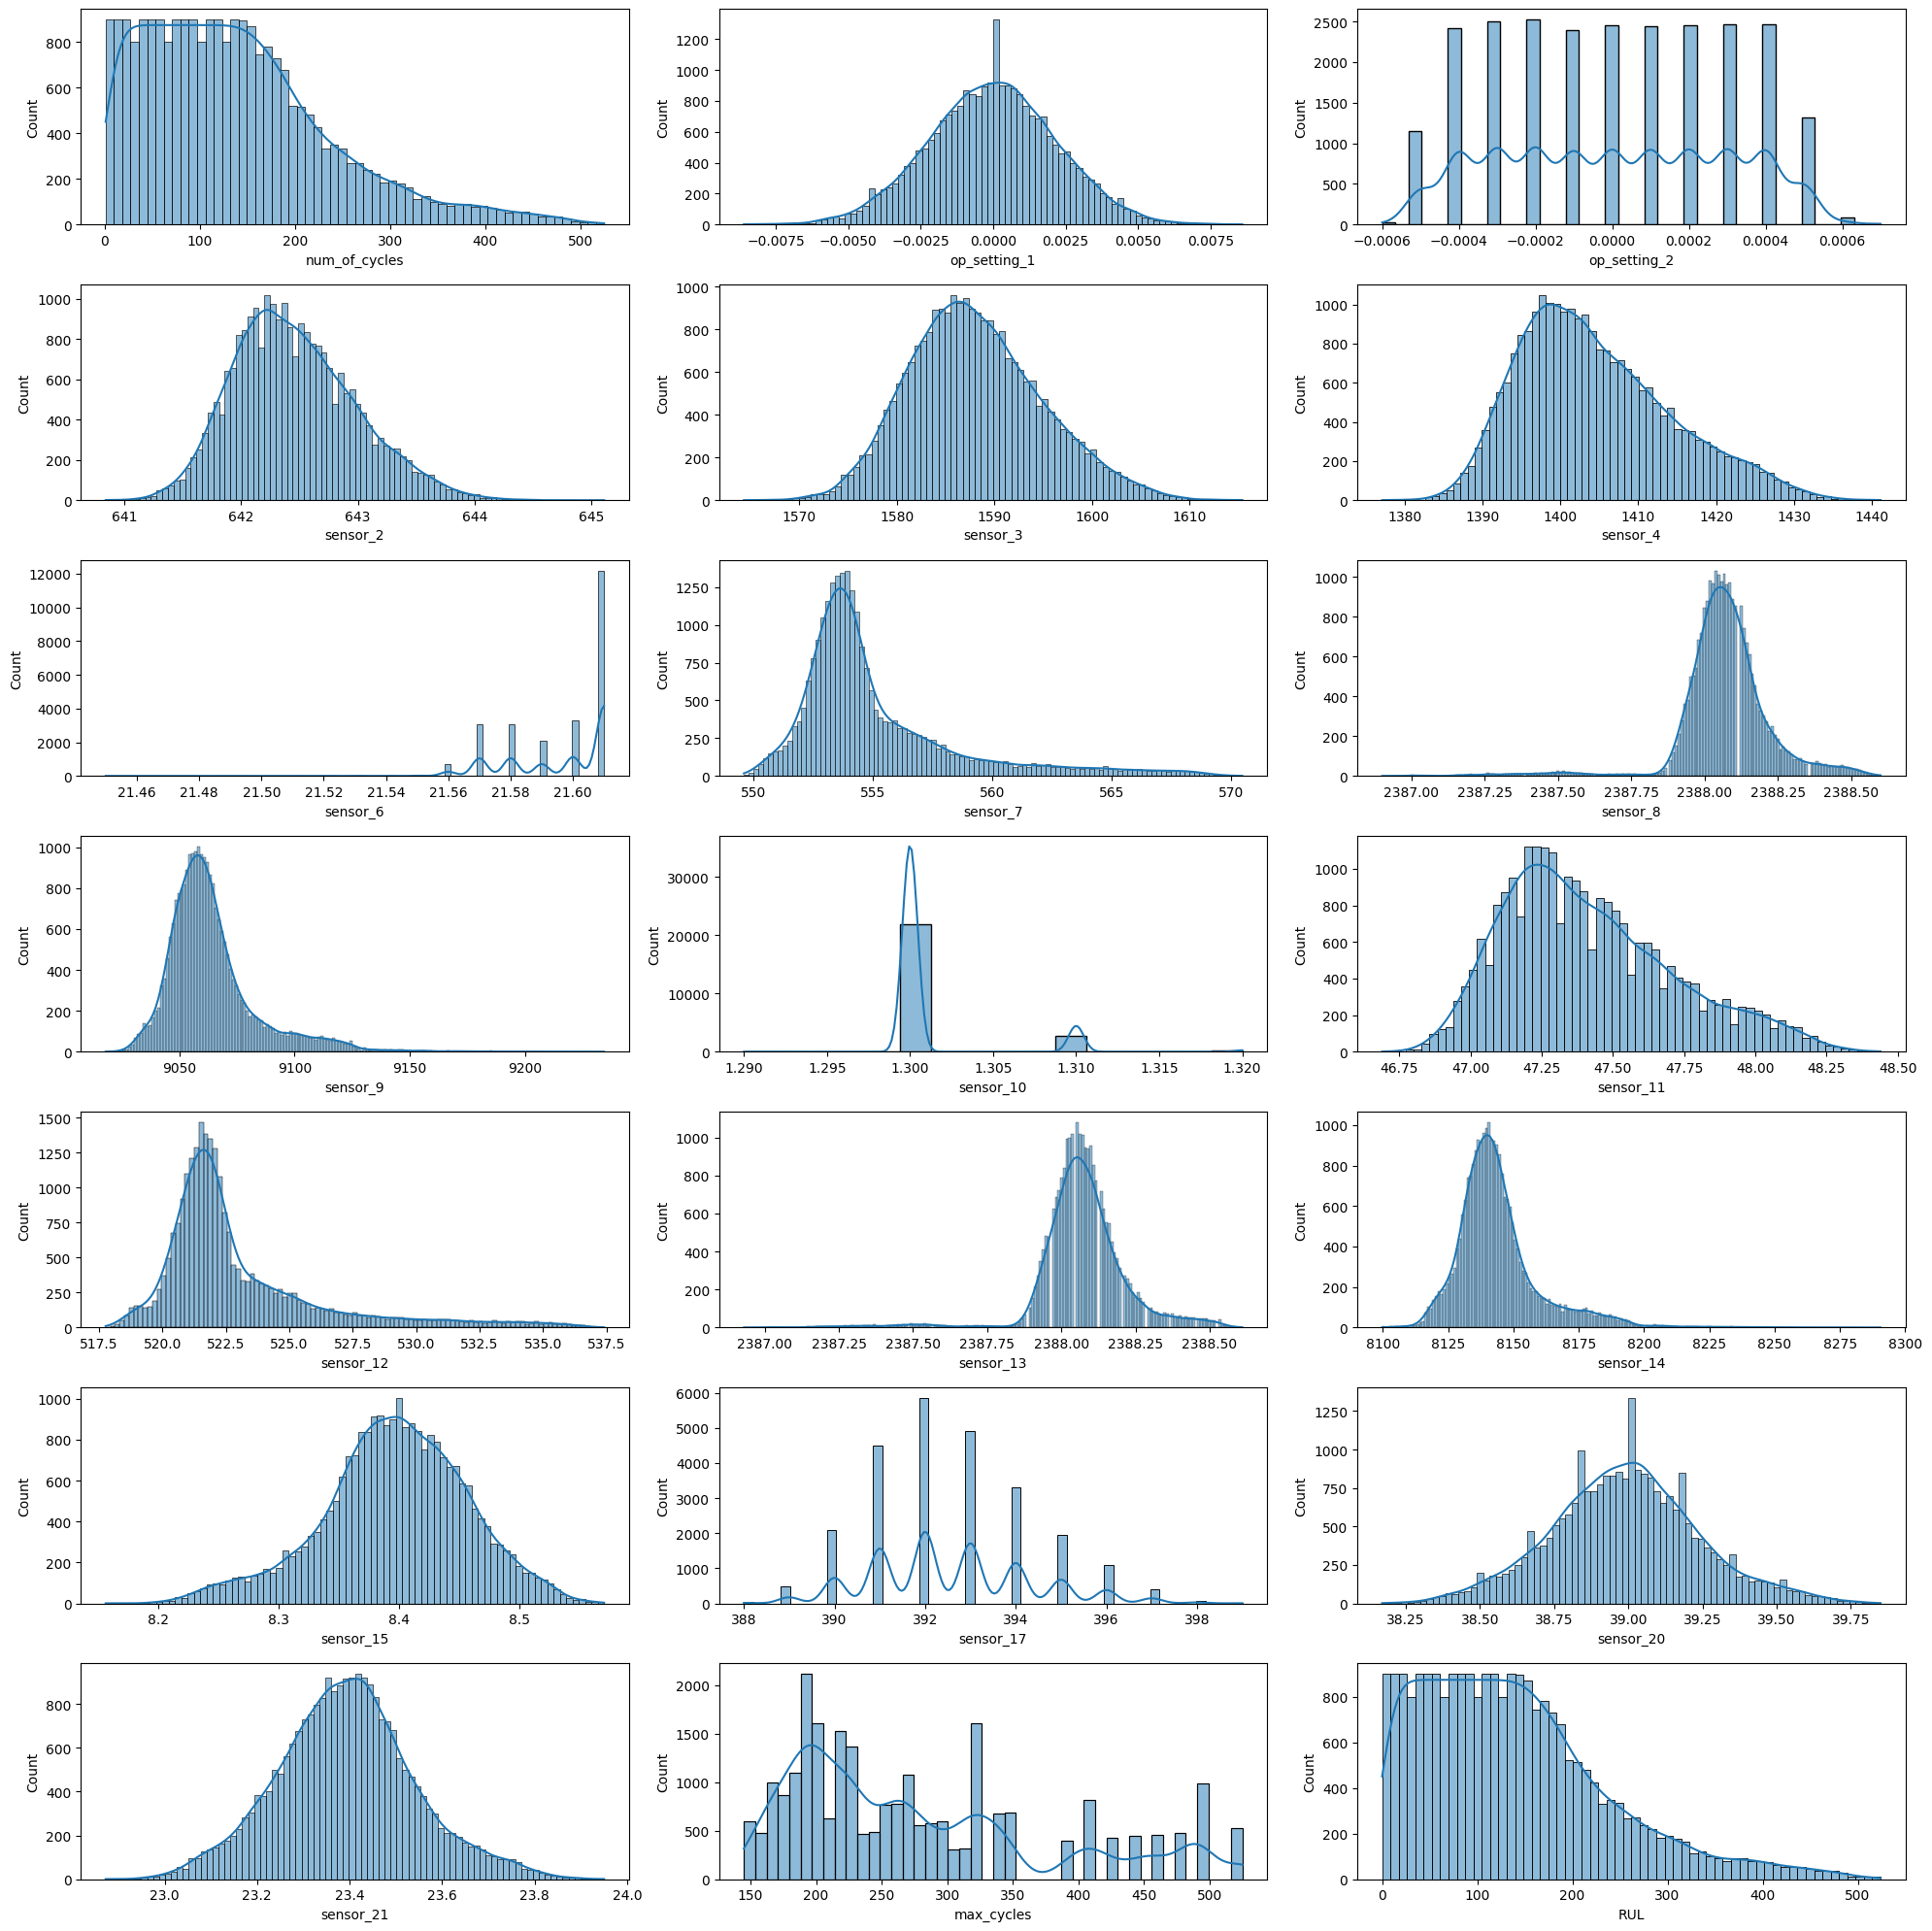

In [26]:
numerical_cols = df.select_dtypes("number").columns

plt.figure(figsize=(20,20))

for i, col in enumerate(numerical_cols, 1):

    plt.subplot(7, 3, i)
    sns.histplot(df[col], kde=True)
    plt.tight_layout()

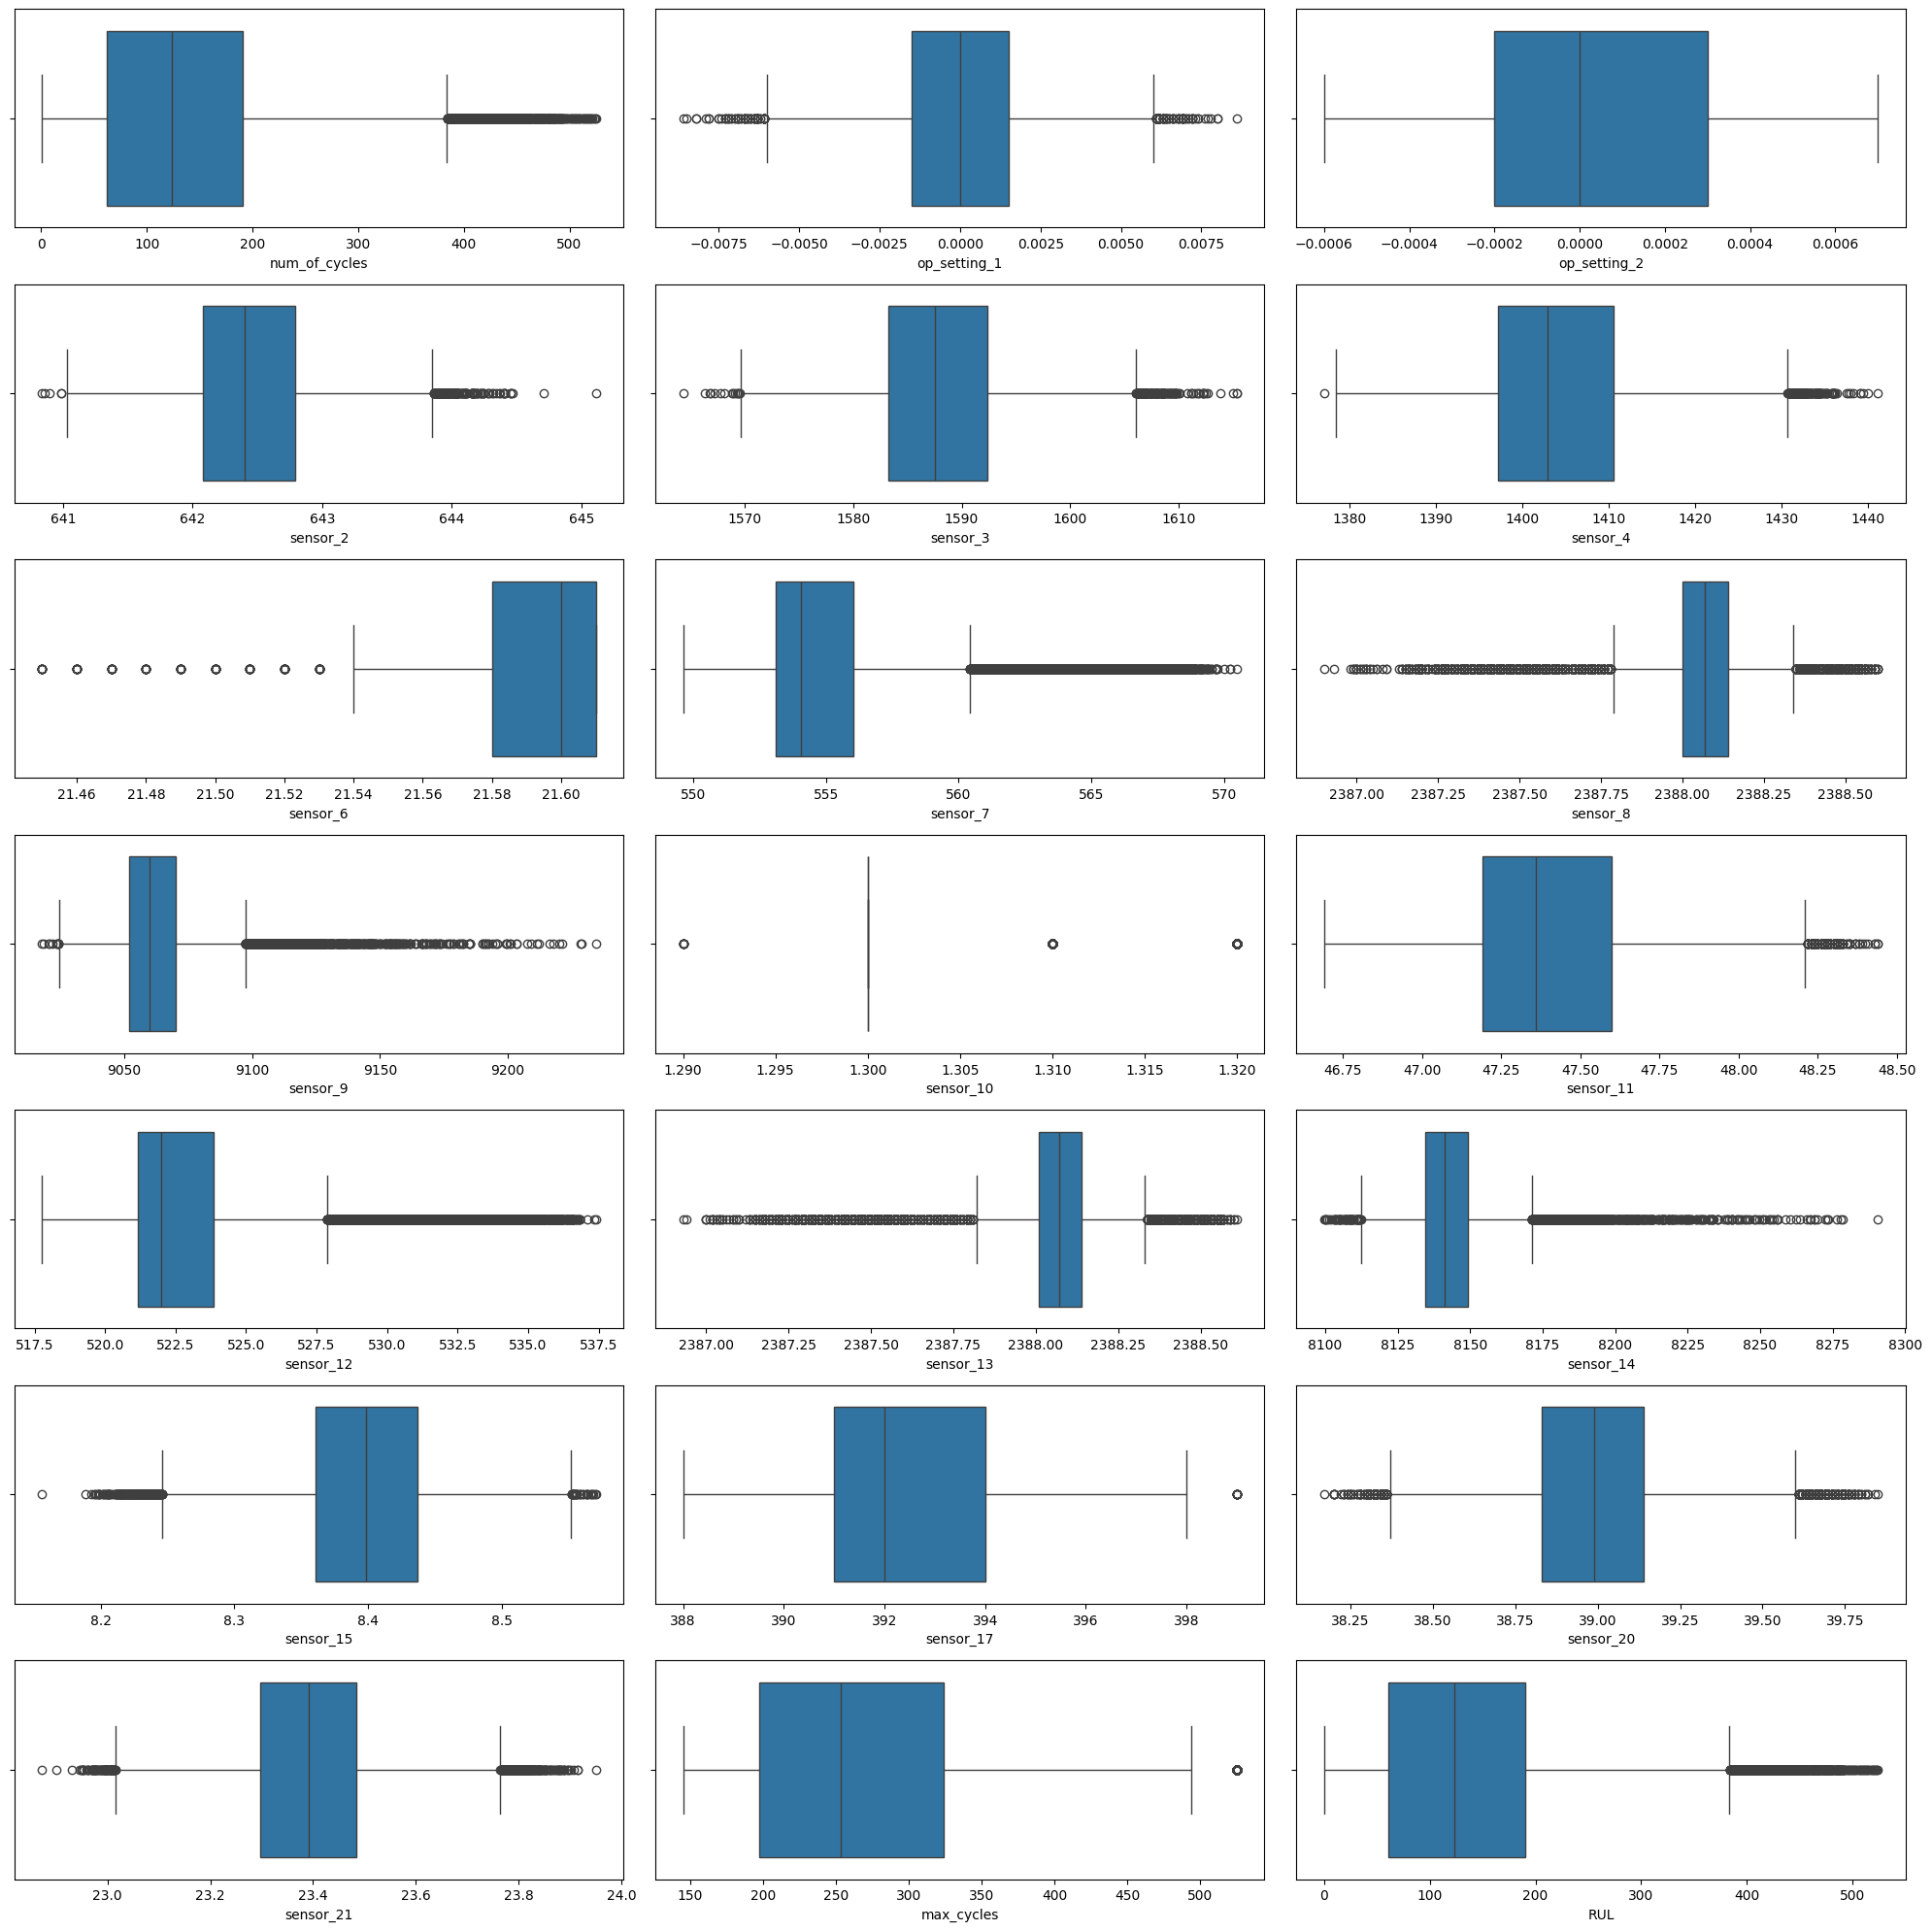

In [27]:
numerical_cols = df.select_dtypes("number").columns

plt.figure(figsize=(20,20))

for i, col in enumerate(numerical_cols, 1):

    plt.subplot(7, 3, i)
    sns.boxplot(x=df[col])
    plt.tight_layout()

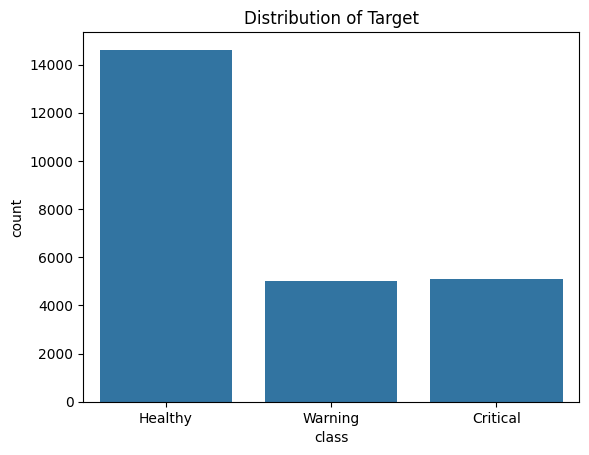

In [28]:
sns.countplot(x=df['class'])
plt.title("Distribution of Target")
plt.show()

### 2-Bivariate Analysis

In [29]:
numerical_df= df.drop("class",axis=1)
numerical_df.corr()

,num_of_cycles,op_setting_1,op_setting_2,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,...,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,max_cycles,RUL
num_of_cycles,1.000000,-0.003217,0.003486,0.300800,0.373484,0.361911,-0.418568,0.531018,0.438092,0.507853,...,0.407408,0.538206,0.437559,0.488587,-0.400585,0.386156,0.304626,0.311018,0.508565,-0.482709
op_setting_1,-0.003217,1.000000,0.001238,-0.002099,-0.004160,0.000804,-0.000044,-0.002501,-0.001351,-0.007729,...,-0.003291,-0.003290,-0.002471,-0.008938,0.007108,0.001672,-0.005602,-0.001454,0.000486,0.003711
op_setting_2,0.003486,0.001238,1.000000,0.005127,0.005225,0.004171,-0.006072,-0.002428,0.000666,0.012316,...,0.002216,-0.001321,-0.001392,0.015840,0.002083,0.003127,-0.001058,-0.003549,0.002179,-0.001270
sensor_2,0.300800,-0.002099,0.005127,1.000000,0.640505,0.745171,0.314809,0.124165,0.533915,0.441282,...,0.762269,0.141784,0.532744,0.343955,0.232952,0.670066,-0.246284,-0.241321,-0.284893,-0.590573
sensor_3,0.373484,-0.004160,0.005225,0.640505,1.000000,0.716884,0.269491,0.282000,0.637918,0.535077,...,0.746092,0.298938,0.636511,0.454212,0.076834,0.677208,-0.091838,-0.089044,-0.246520,-0.624226
sensor_4,0.361911,0.000804,0.004171,0.745171,0.716884,1.000000,0.319171,0.181968,0.601264,0.509786,...,0.854031,0.202102,0.601251,0.404693,0.216791,0.749901,-0.235004,-0.230146,-0.290330,-0.657213
sensor_6,-0.418568,-0.000044,-0.006072,0.314809,0.269491,0.319171,1.000000,-0.208683,0.247508,0.065135,...,0.305794,-0.200901,0.247115,0.008577,0.485670,0.285694,-0.345933,-0.347736,-0.623280,-0.215399
sensor_7,0.531018,-0.002501,-0.002428,0.124165,0.282000,0.181968,-0.208683,1.000000,0.596507,0.579004,...,0.270770,0.988725,0.597166,0.601015,-0.826573,0.285789,0.802850,0.807137,0.212332,-0.315042
sensor_8,0.438092,-0.001351,0.000666,0.533915,0.637918,0.601264,0.247508,0.596507,1.000000,0.578590,...,0.660207,0.608298,0.964053,0.519631,-0.238358,0.662610,0.241743,0.244543,-0.213587,-0.655336
sensor_9,0.507853,-0.007729,0.012316,0.441282,0.535077,0.509786,0.065135,0.579004,0.578590,1.000000,...,0.546840,0.590891,0.578325,0.954354,-0.287941,0.559114,0.263303,0.271764,-0.043266,-0.551855


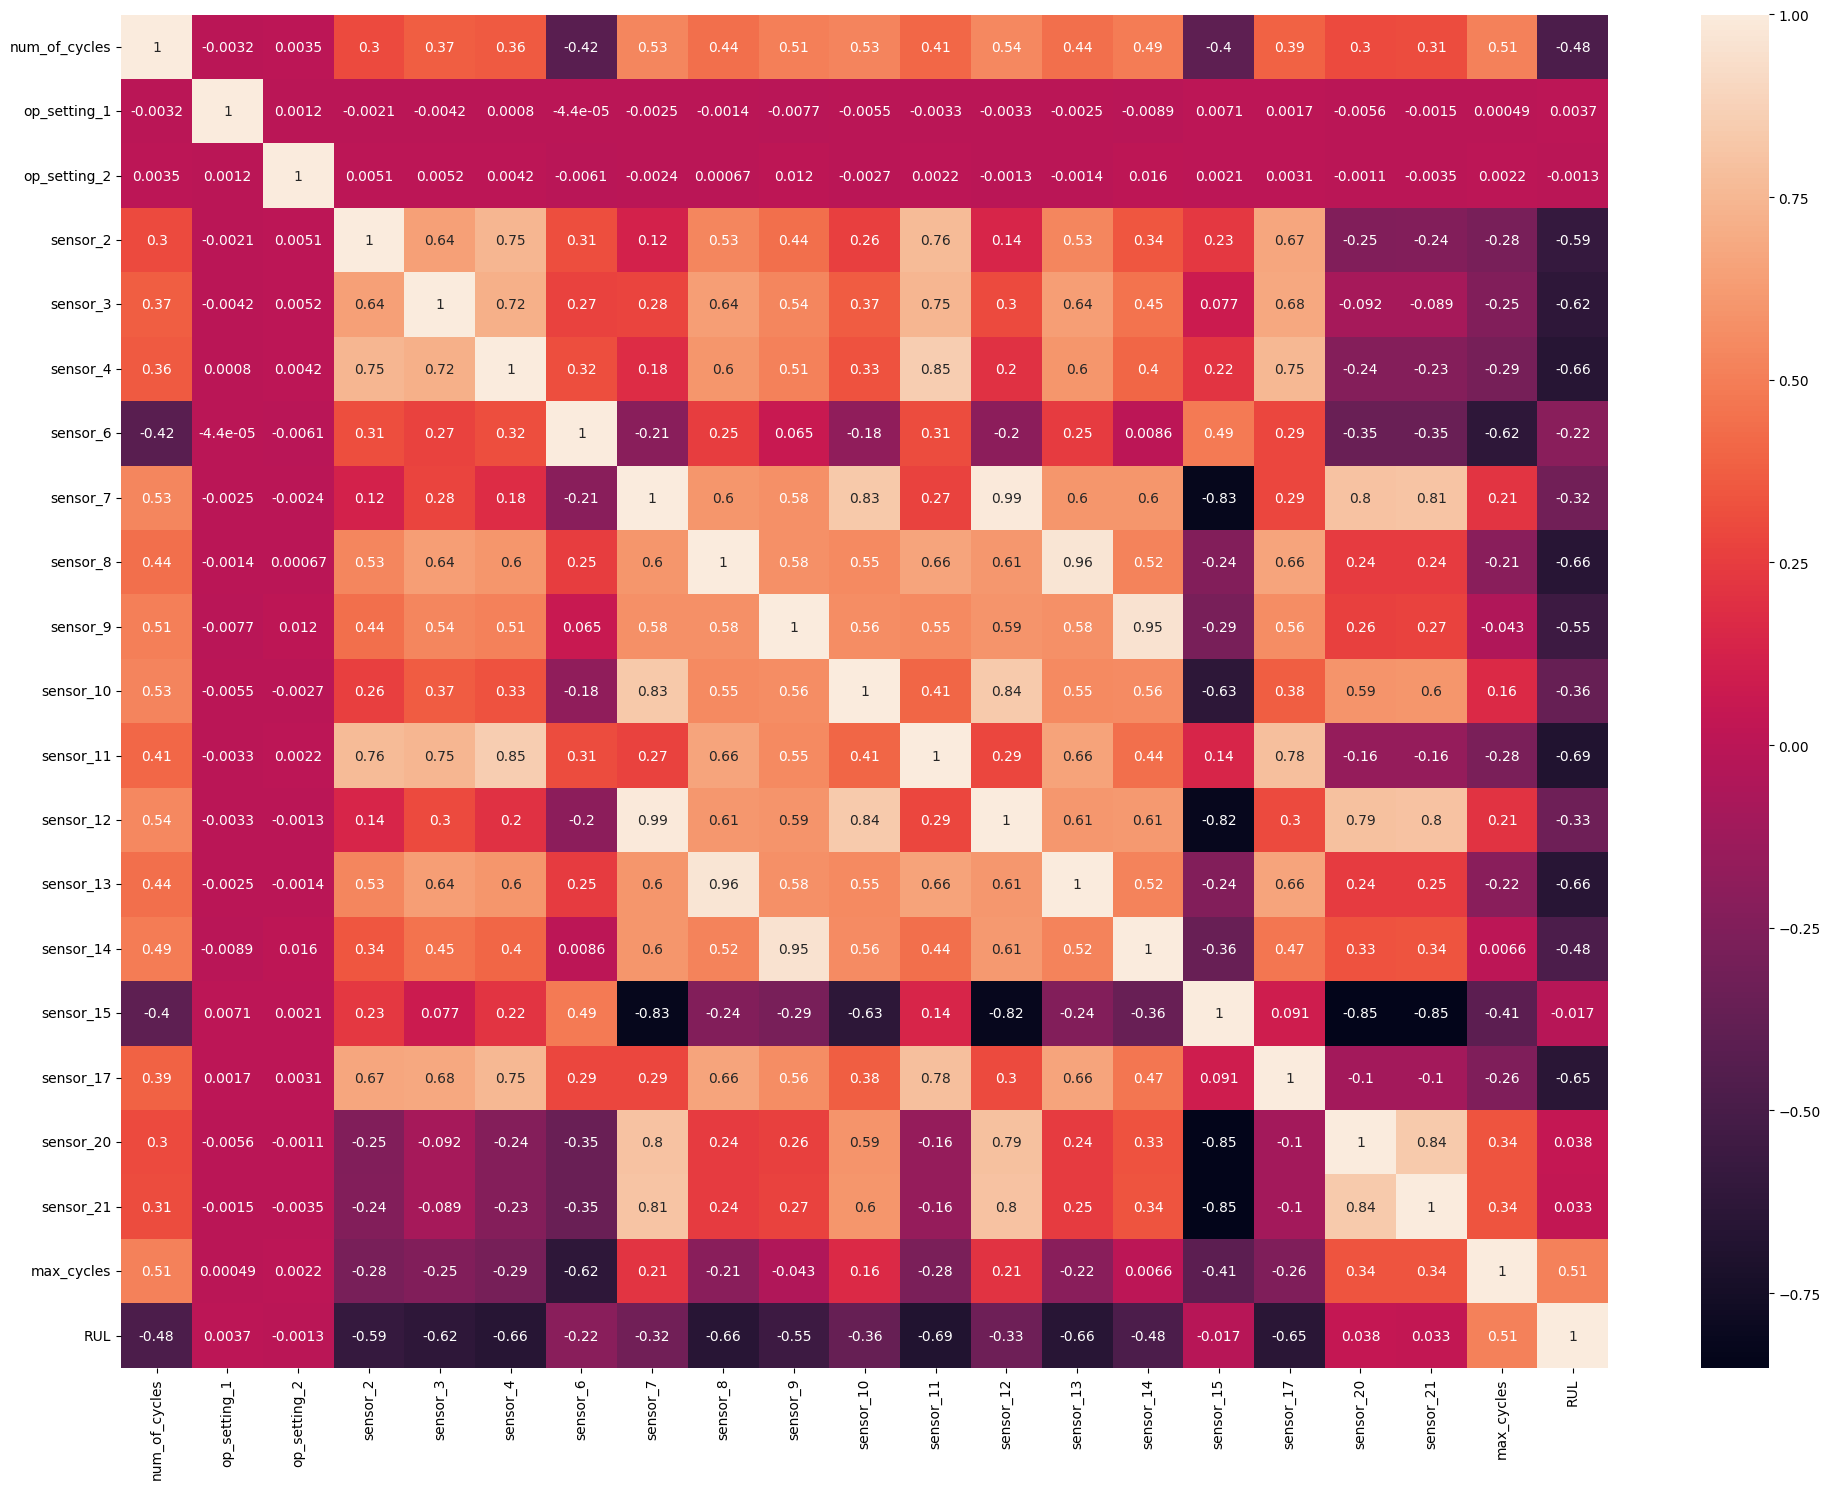

In [30]:
plt.figure(figsize=(20, 15))
sns.heatmap(numerical_df.corr(), annot=True)
plt.tight_layout()
plt.show()

In [31]:
numerical_df.corr()['RUL'].sort_values()

,RUL
sensor_11,-0.688919
sensor_4,-0.657213
sensor_13,-0.656342
sensor_8,-0.655336
sensor_17,-0.649206
sensor_3,-0.624226
sensor_2,-0.590573
sensor_9,-0.551855
num_of_cycles,-0.482709
sensor_14,-0.481825


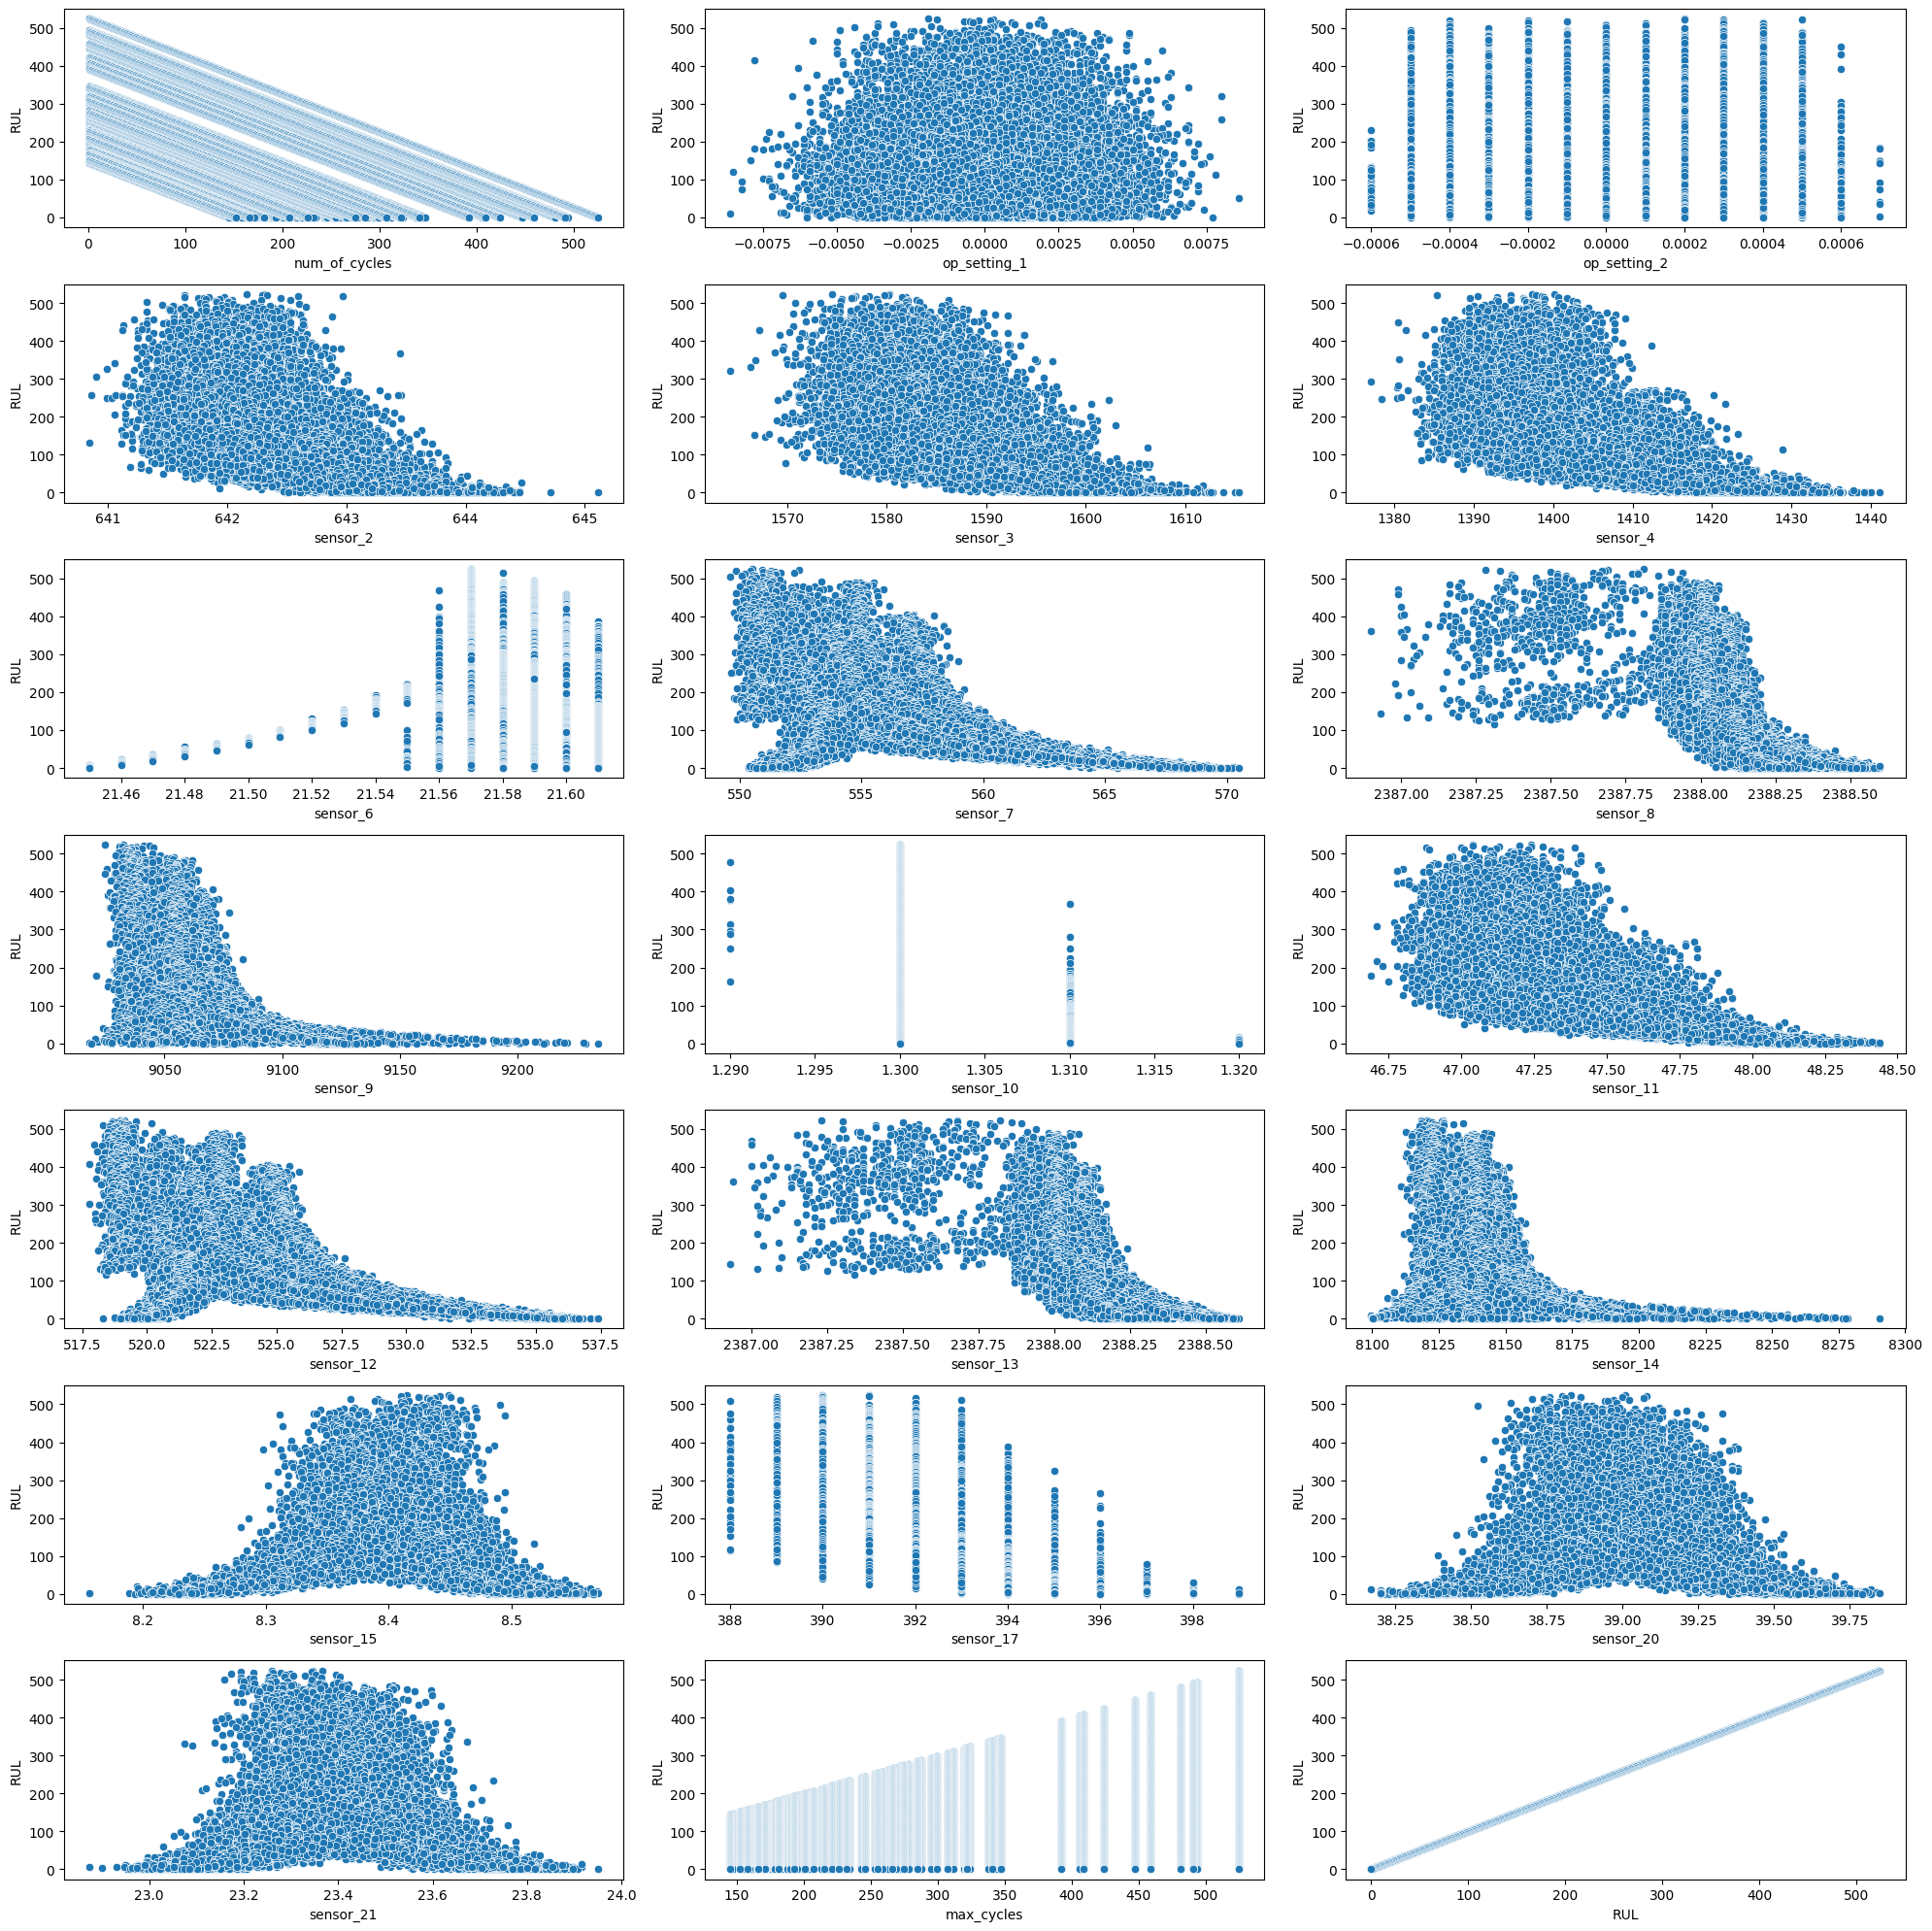

In [32]:
plt.figure(figsize=(20,20))

for i, col in enumerate(numerical_cols, 1):

    plt.subplot(7, 3, i)
    sns.scatterplot(data=df,x=col,y="RUL")
    plt.tight_layout()

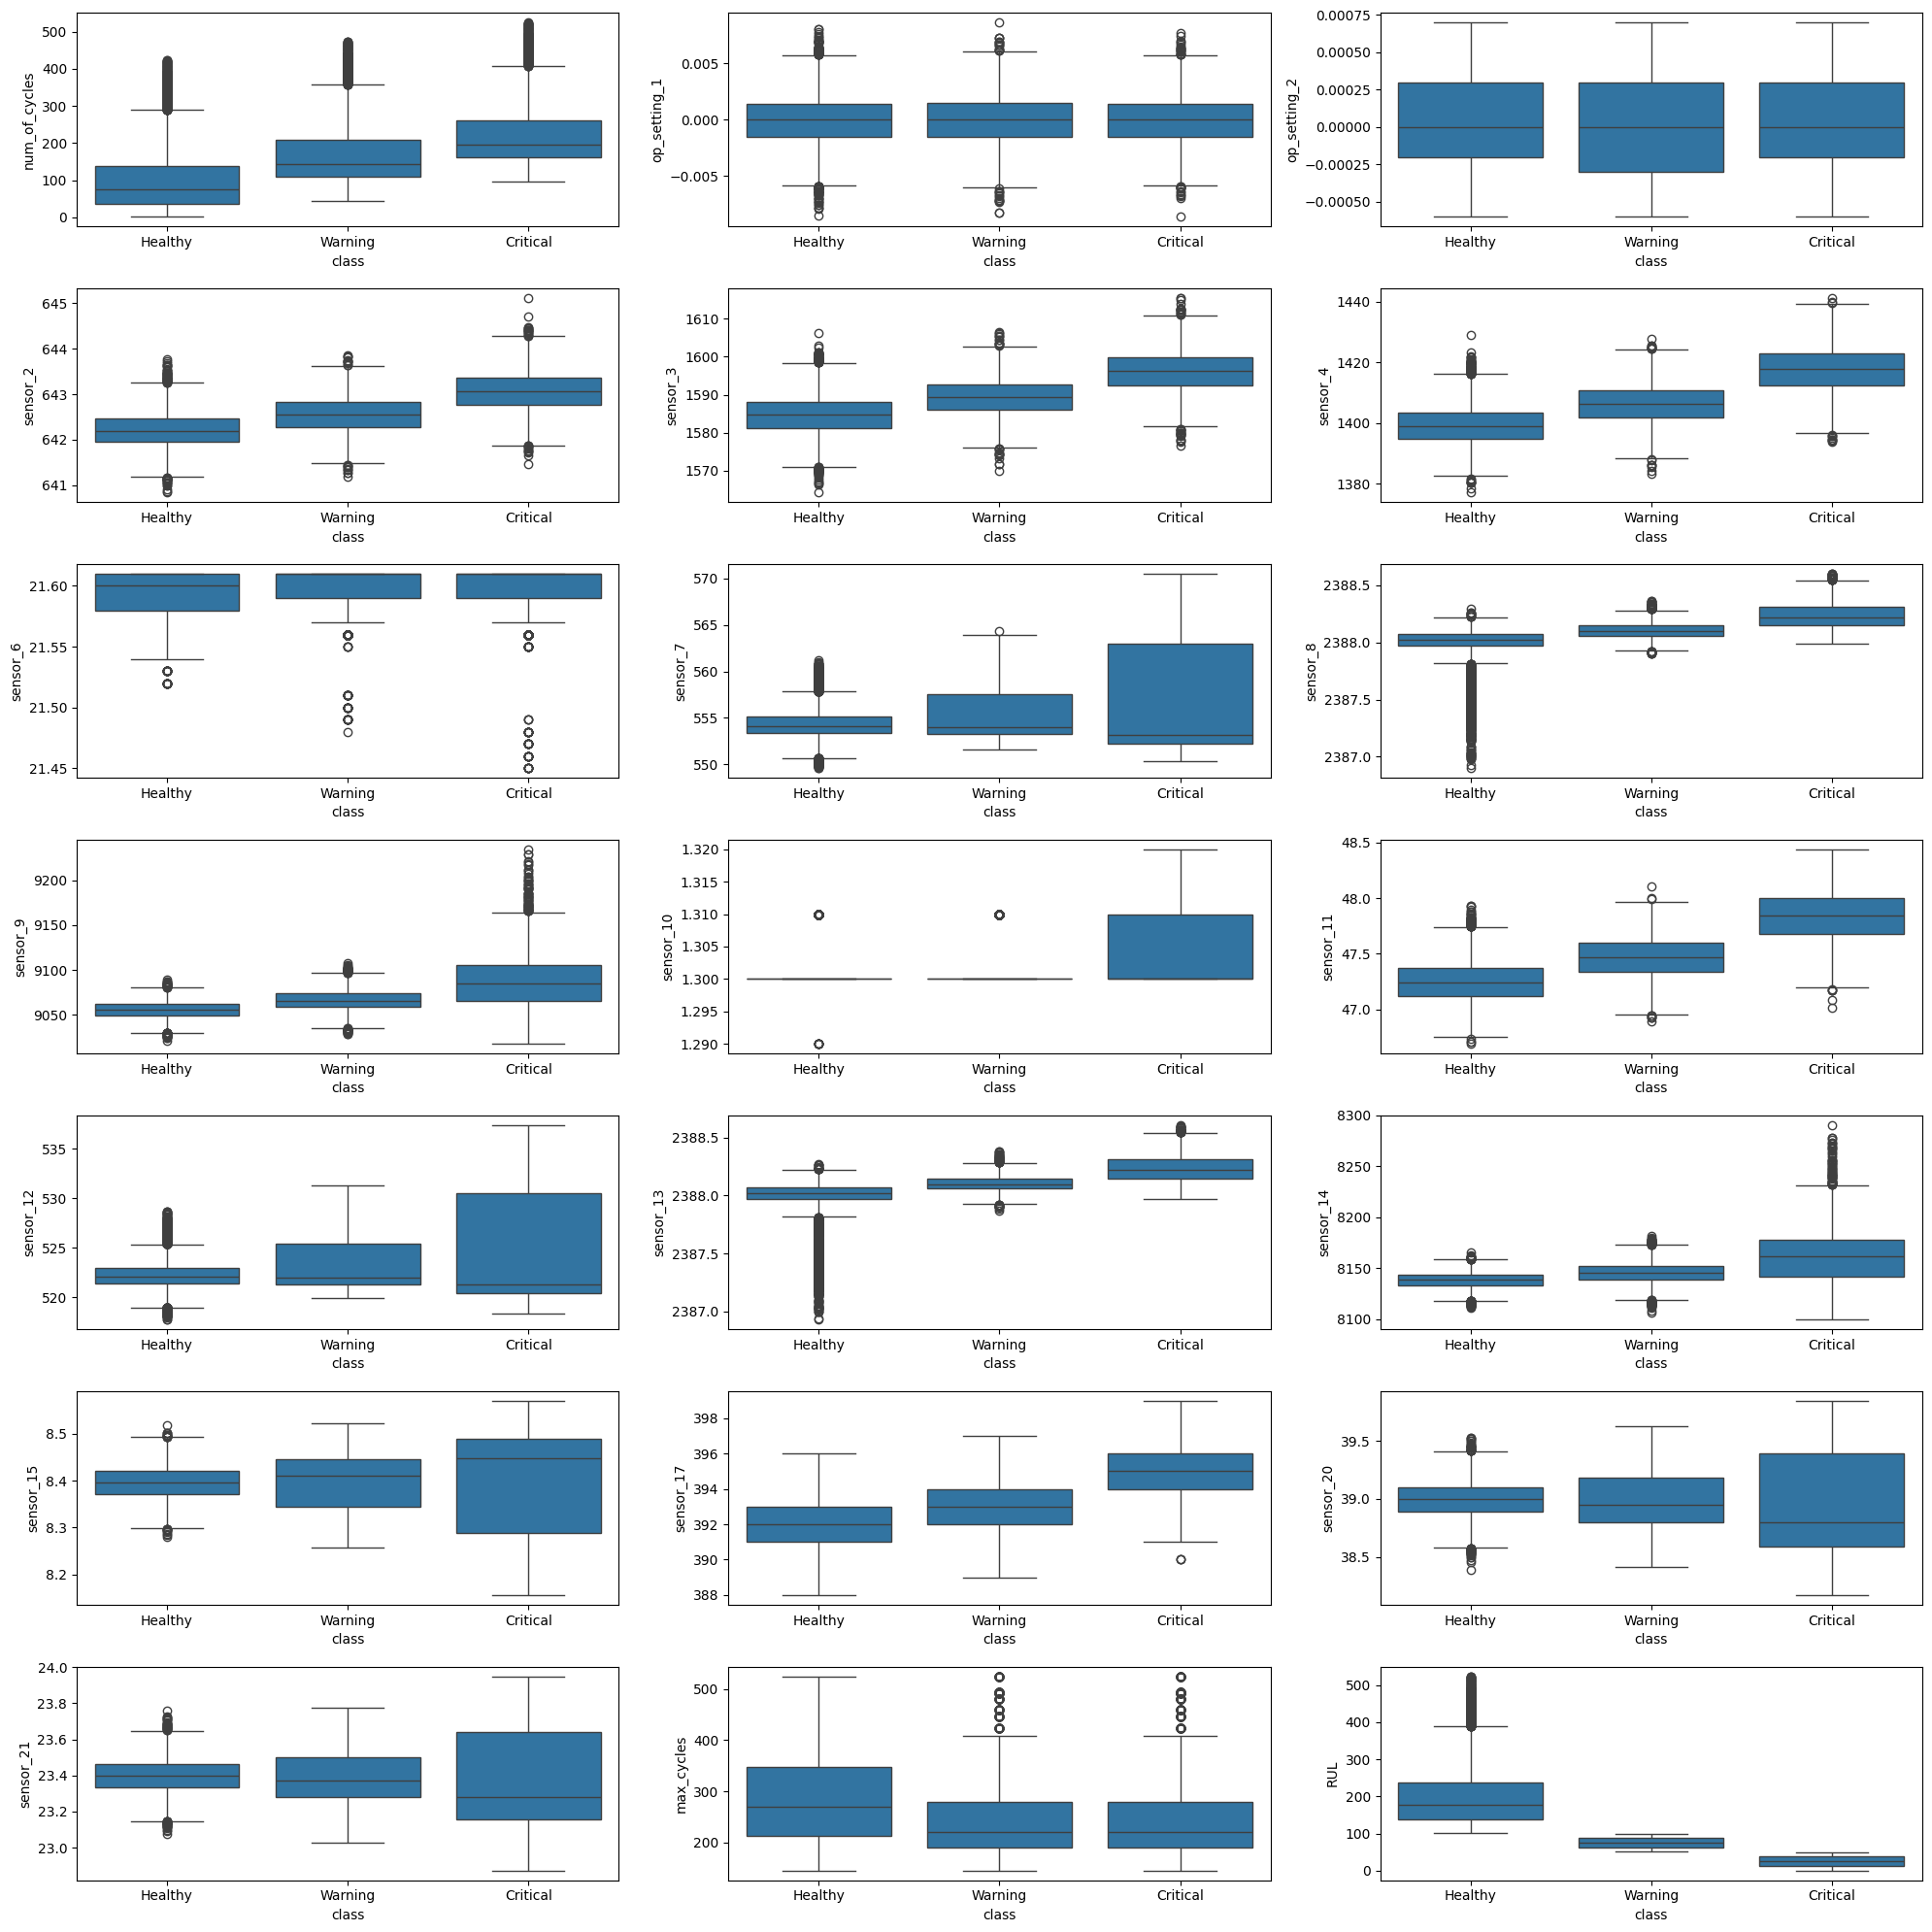

In [33]:
numerical_cols = df.select_dtypes("number").columns

plt.figure(figsize=(20,20))

for i, col in enumerate(numerical_cols, 1):

    plt.subplot(7, 3, i)
    sns.boxplot(data=df,x="class",y=col)
    plt.tight_layout()

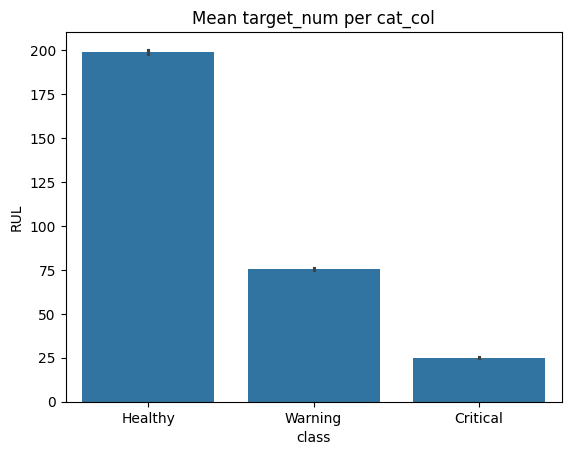

In [34]:
sns.barplot(data=df, x='class', y='RUL', estimator='mean')
plt.title('Mean target_num per cat_col')
plt.show()

In [35]:
df.groupby('class').agg(["min","max","mean","median","std"])

num_of_cycles                                    op_setting_1  \
                   min  max        mean median        std          min   
class                                                                    
Critical            95  525  222.200000  195.0  87.308770      -0.0086   
Healthy              1  424   98.930433   76.0  82.894334      -0.0085   
Warning             45  474  171.700000  144.0  87.260718      -0.0082   

                                             ... max_cycles                   \
             max      mean median       std  ...        min  max        mean   
class                                        ...                               
Critical  0.0077 -0.000015    0.0  0.002200  ...        145  525  247.200000   
Healthy   0.0080 -0.000025    0.0  0.002176  ...        145  525  297.850127   
Warning   0.0086 -0.000030    0.0  0.002238  ...        145  525  247.200000   

                             RUL                                     
         median         std  min  max        mean median        std  
class                                                                
Critical  220.5   86.058772    0   50   25.000000   25.0  14.721045  
Healthy   269.0  104.536929  101  524  198.919694  176.0  82.896850  
Warning   220.5   86.058940   51  100   75.500000   75.5  14.432313  

[3 rows x 105 columns]

### 3-Multivariate Analysis

In [36]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
numerical_cols=numerical_cols = df.select_dtypes("number").columns.drop("RUL")
X = df[numerical_cols]

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print(vif_data)

          feature           VIF
0   num_of_cycles  1.117776e+01
1    op_setting_1  1.000729e+00
2    op_setting_2  1.001149e+00
3        sensor_2  4.213254e+06
4        sensor_3  1.437881e+05
5        sensor_4  9.749595e+04
6        sensor_6  3.501848e+06
7        sensor_7  1.257853e+06
8        sensor_8  3.173354e+09
9        sensor_9  3.089876e+06
10      sensor_10  5.370280e+05
11      sensor_11  1.488714e+05
12      sensor_12  1.345280e+06
13      sensor_13  3.171593e+09
14      sensor_14  3.186676e+06
15      sensor_15  1.616542e+05
16      sensor_17  1.553525e+05
17      sensor_20  1.402343e+05
18      sensor_21  1.441226e+05
19     max_cycles  2.161622e+01


In [37]:
# Identify numeric columns
num_cols = df.select_dtypes(include=np.number).columns
print("Numeric columns:")
print(num_cols)


Numeric columns:
Index(['num_of_cycles', 'op_setting_1', 'op_setting_2', 'sensor_2', 'sensor_3',
       'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10',
       'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15',
       'sensor_17', 'sensor_20', 'sensor_21', 'max_cycles', 'RUL'],
      dtype='object')


In [38]:
# Z-score method
z_scores = np.abs(stats.zscore(df[num_cols]))
outliers_z = (z_scores > 3).sum(axis=0)
print("Outliers detected by Z-score method per column:")
print(outliers_z)


Outliers detected by Z-score method per column:
[287  65   0  81  57  50 182 655 579 367 166  31 691 570 334  43  90  58
  47   0 287]


In [39]:

# IQR method
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

outliers_iqr = ((df[num_cols] < (Q1 - 1.5*IQR)) | (df[num_cols] > (Q3 + 1.5*IQR))).sum()
print("Outliers detected by IQR method per column:")
print(outliers_iqr)


Outliers detected by IQR method per column:
num_of_cycles     688
op_setting_1      133
op_setting_2        0
sensor_2          190
sensor_3          180
sensor_4          173
sensor_6          151
sensor_7         2188
sensor_8         1714
sensor_9         1844
sensor_10        2906
sensor_11         153
sensor_12        2276
sensor_13        1820
sensor_14        1863
sensor_15         406
sensor_17          11
sensor_20         381
sensor_21         351
max_cycles        525
RUL               688
dtype: int64


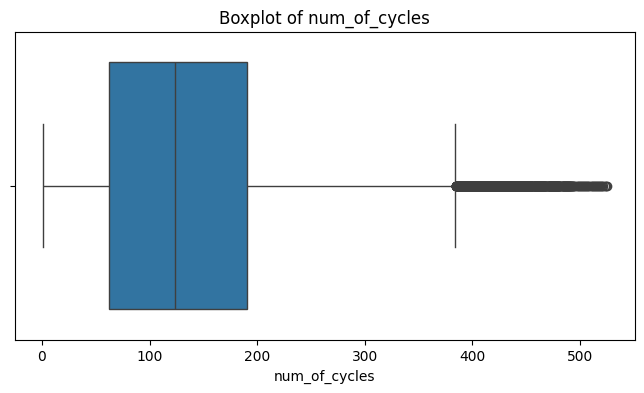

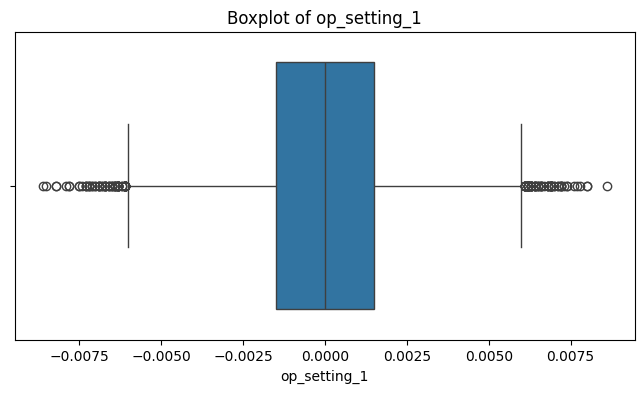

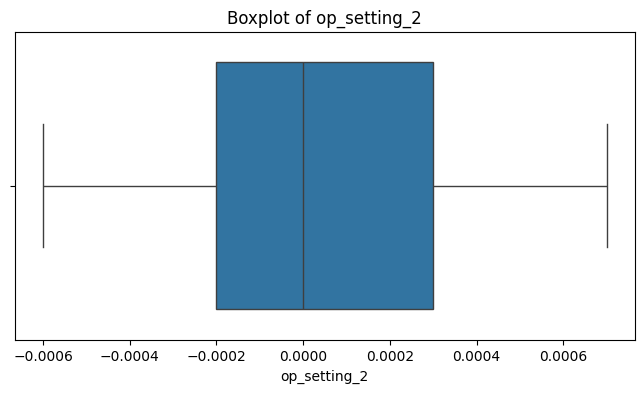

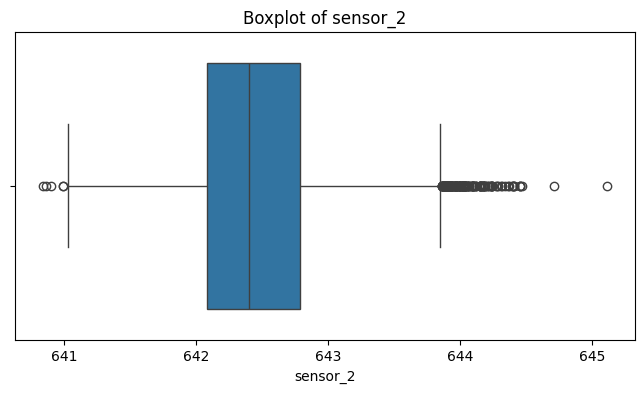

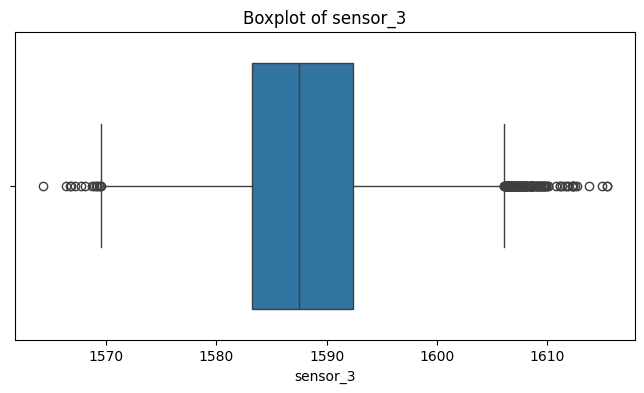

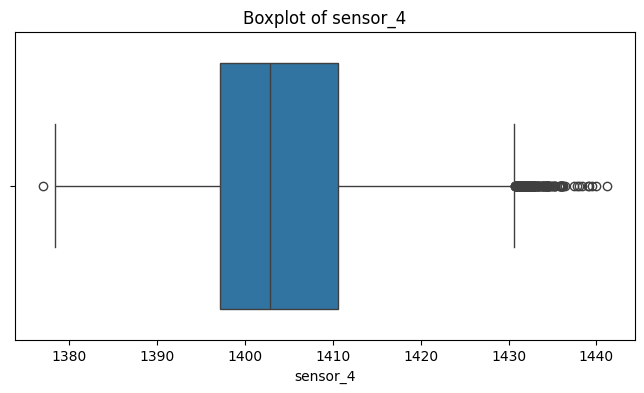

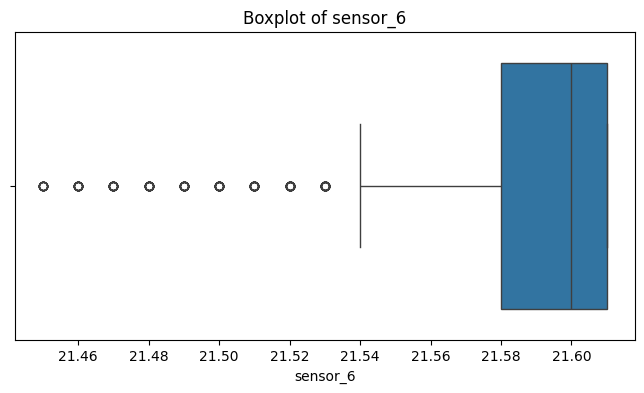

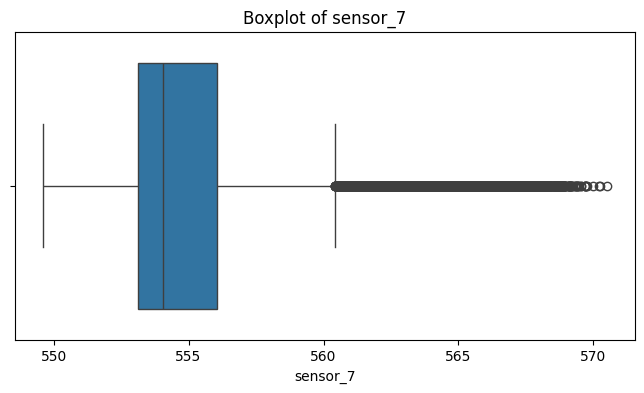

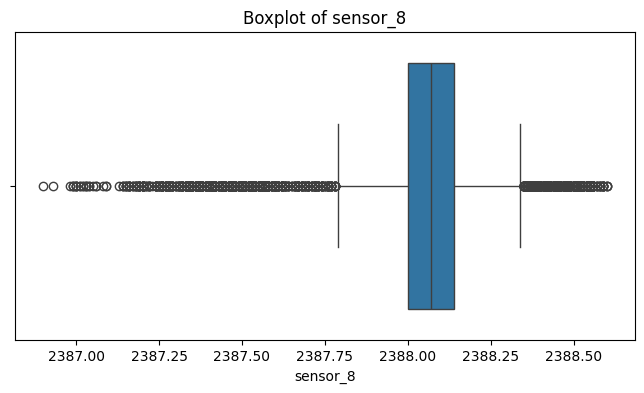

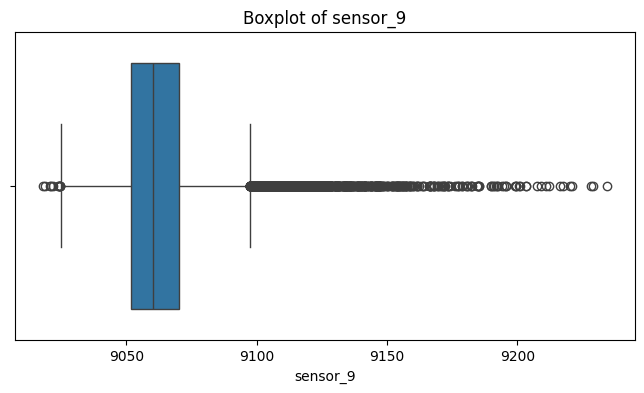

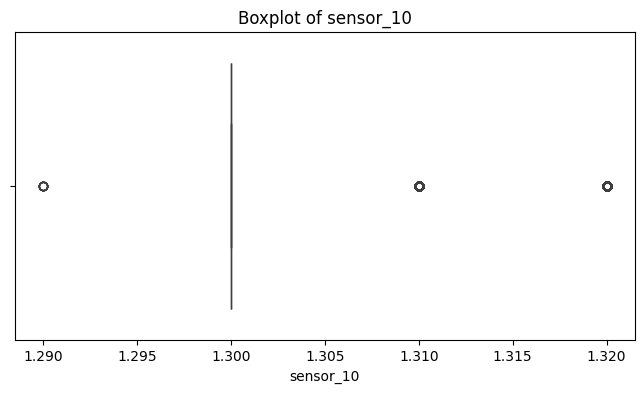

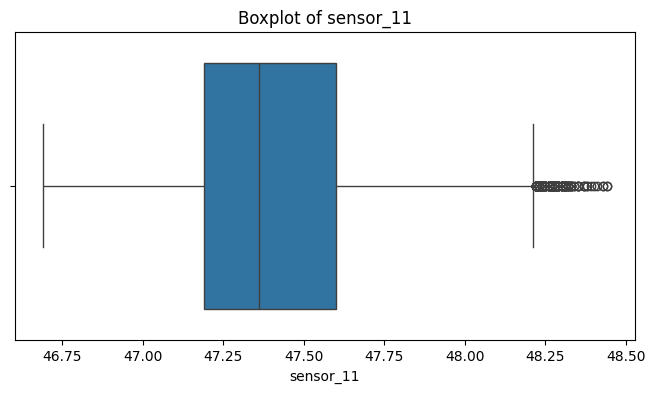

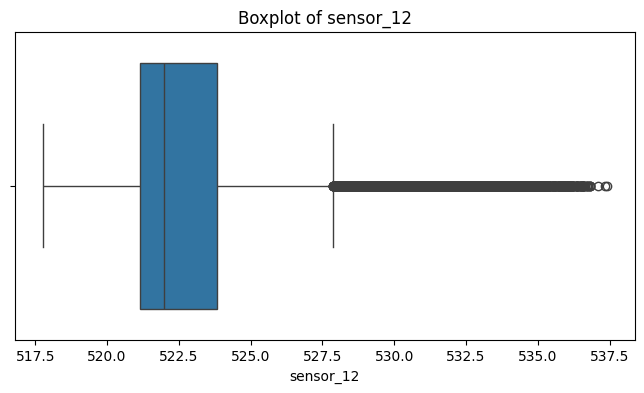

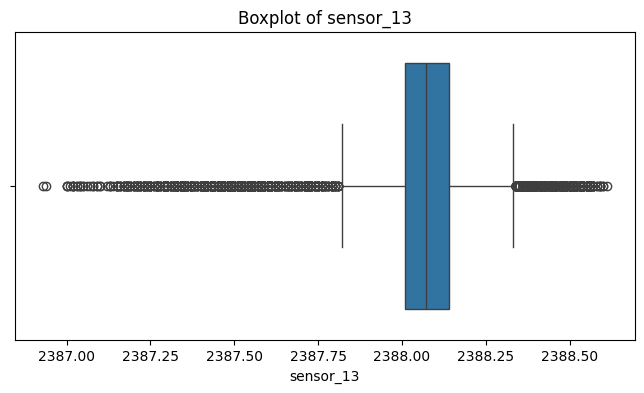

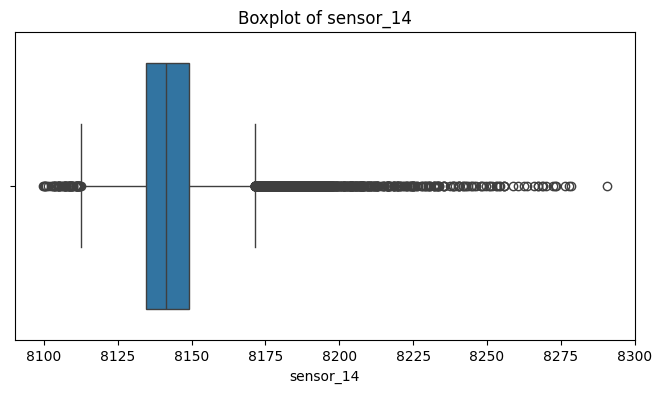

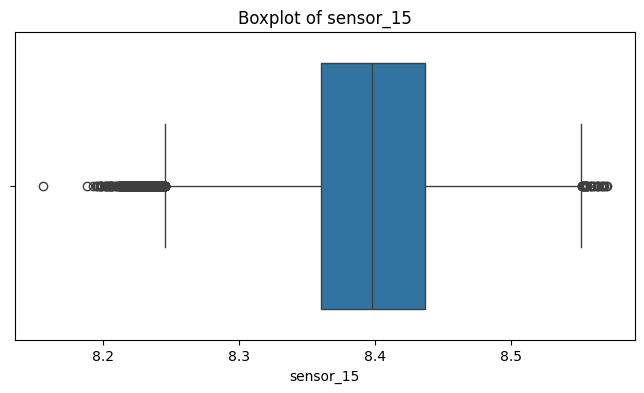

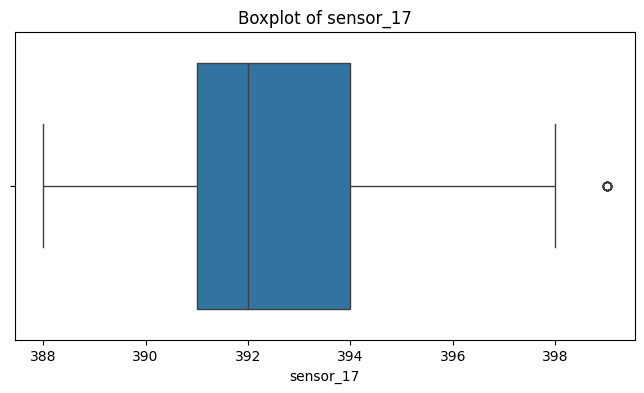

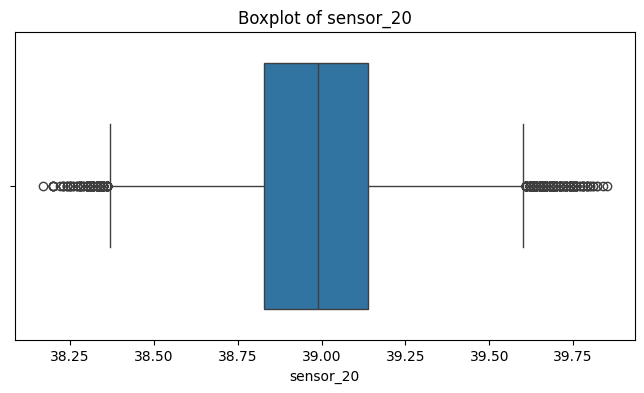

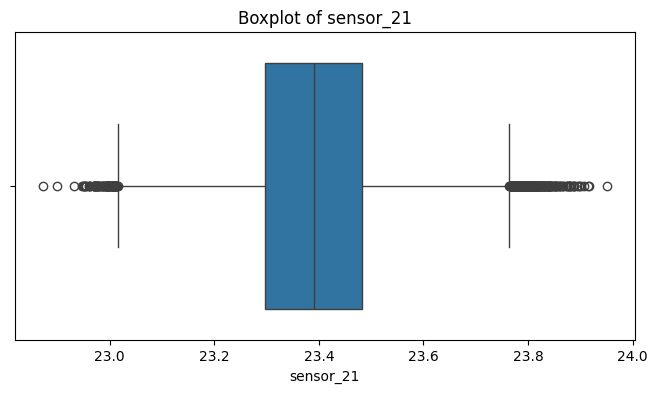

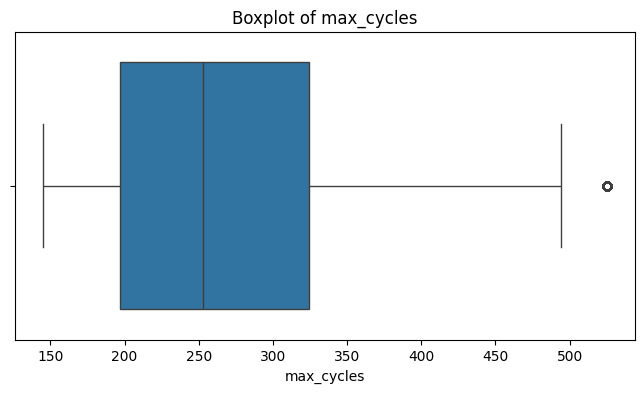

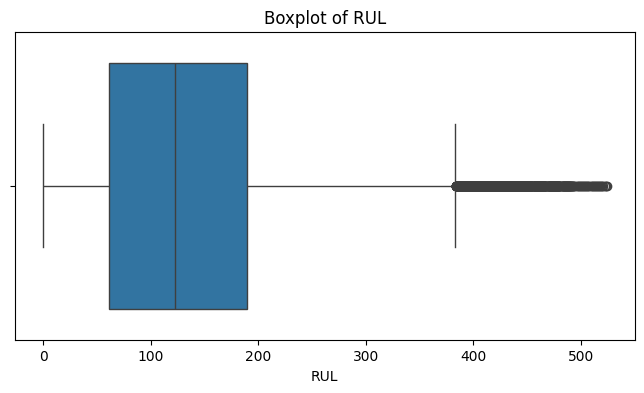

In [40]:

import matplotlib.pyplot as plt
import seaborn as sns

for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [41]:
# Check for negative values
for col in num_cols:
    if (df[col] < 0).any():
        print(f"Negative values found in column {col}")


Negative values found in column op_setting_1
Negative values found in column op_setting_2


In [42]:

# Rare categories for numeric columns with few unique values
for col in num_cols:
    if df[col].nunique() < 20:
        value_counts = df[col].value_counts(normalize=True)
        rare = value_counts[value_counts < 0.01]
        if not rare.empty:
            print(f"Rare categories in {col}:")
            print(rare)


Rare categories in op_setting_2:
op_setting_2
 0.0006    0.003317
-0.0006    0.001133
 0.0007    0.000405
Name: proportion, dtype: float64
Rare categories in sensor_6:
sensor_6
21.55    0.002306
21.54    0.001254
21.53    0.001052
21.52    0.000971
21.51    0.000809
21.50    0.000647
21.49    0.000647
21.48    0.000566
21.47    0.000566
21.46    0.000485
21.45    0.000364
Name: proportion, dtype: float64
Rare categories in sensor_10:
sensor_10
1.32    0.006351
1.29    0.000364
Name: proportion, dtype: float64
Rare categories in sensor_17:
sensor_17
398    0.003196
388    0.001618
399    0.000445
Name: proportion, dtype: float64


In [43]:
#!pip install ydata-profiling

In [44]:
# Optional: Automated EDA report using ydata_profiling
'''
import ydata_profiling
profile = ydata_profiling.ProfileReport(df)
profile.to_widgets()
profile.to_file("eda_report.html")'''




'\nimport ydata_profiling\nprofile = ydata_profiling.ProfileReport(df)\nprofile.to_widgets()\nprofile.to_file("eda_report.html")'

In [45]:
# Correlation of numeric features with RUL
correlations = df[num_cols].corr()["RUL"].sort_values(ascending=False)
print("Correlation of numeric features with RUL:")
print(correlations)



Correlation of numeric features with RUL:
RUL              1.000000
max_cycles       0.508579
sensor_20        0.037760
sensor_21        0.033479
op_setting_1     0.003711
op_setting_2    -0.001270
sensor_15       -0.016524
sensor_6        -0.215399
sensor_7        -0.315042
sensor_12       -0.329451
sensor_10       -0.363426
sensor_14       -0.481825
num_of_cycles   -0.482709
sensor_9        -0.551855
sensor_2        -0.590573
sensor_3        -0.624226
sensor_17       -0.649206
sensor_8        -0.655336
sensor_13       -0.656342
sensor_4        -0.657213
sensor_11       -0.688919
Name: RUL, dtype: float64


#  4-Data Preprocessing

### 1-Feature Selection

In [46]:
    # Identify columns to drop
no_variance = [col for col in df.columns if df[col].nunique() == 1]
print("\n" + "="*50)
print("FEATURE SELECTION")
print("="*50)
print("Columns with no variance (to drop):", no_variance)


FEATURE SELECTION
Columns with no variance (to drop): []


In [47]:
# Columns to drop
columns_to_drop = ['id', 'max_cycles'] + no_variance
df = df.drop(columns=columns_to_drop, errors='ignore')

print("\nFeatures after initial selection:")
print(df.columns.tolist())


Features after initial selection:
['num_of_cycles', 'op_setting_1', 'op_setting_2', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21', 'RUL', 'class']


###  2- Outlier Detection

In [48]:
print("\n" + "="*50)
print(" OUTLIER DETECTION")
print("="*50)

numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
if 'RUL' in numerical_cols:
    numerical_cols.remove('RUL')  # Don't remove outliers from target
    outliers_summary = {}
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outliers_percentage = (outliers / len(df)) * 100

    if outliers > 0:
        outliers_summary[col] = {
            'outliers': outliers,
            'percentage': outliers_percentage,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound
        }

print(f"Columns with outliers: {len(outliers_summary)} out of {len(numerical_cols)}")
if outliers_summary:
    outliers_df = pd.DataFrame(outliers_summary).T
    print("\nOutliers summary:")
    print(outliers_df[['outliers', 'percentage']].sort_values('percentage', ascending=False).head(10))


 OUTLIER DETECTION
Columns with outliers: 18 out of 19

Outliers summary:
               outliers  percentage
sensor_10        2906.0   11.756139
sensor_12        2276.0    9.207492
sensor_7         2188.0    8.851491
sensor_14        1863.0    7.536713
sensor_9         1844.0    7.459849
sensor_13        1820.0    7.362757
sensor_8         1714.0    6.933937
num_of_cycles     688.0    2.783284
sensor_15         406.0    1.642461
sensor_20         381.0    1.541324


### 3- Handle Outliers

In [49]:
print("\n" + "="*50)
print("OUTLIER TREATMENT")
print("="*50)

numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
if 'RUL' in numerical_cols:
    numerical_cols.remove('RUL')

total_outliers = 0

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers before capping
    outliers_before = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()

    if outliers_before > 0:
        print(f"{col}: {outliers_before} outliers ({outliers_before/len(df)*100:.2f}%)")
        total_outliers += outliers_before

    # Apply capping
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

print(f"\nTotal outliers handled: {total_outliers}")
print(f"Total rows in dataset: {len(df)}")
print("="*50)


OUTLIER TREATMENT
num_of_cycles: 688 outliers (2.78%)
op_setting_1: 133 outliers (0.54%)
sensor_2: 190 outliers (0.77%)
sensor_3: 180 outliers (0.73%)
sensor_4: 173 outliers (0.70%)
sensor_6: 151 outliers (0.61%)
sensor_7: 2188 outliers (8.85%)
sensor_8: 1714 outliers (6.93%)
sensor_9: 1844 outliers (7.46%)
sensor_10: 2906 outliers (11.76%)
sensor_11: 153 outliers (0.62%)
sensor_12: 2276 outliers (9.21%)
sensor_13: 1820 outliers (7.36%)
sensor_14: 1863 outliers (7.54%)
sensor_15: 406 outliers (1.64%)
sensor_17: 11 outliers (0.04%)
sensor_20: 381 outliers (1.54%)
sensor_21: 351 outliers (1.42%)

Total outliers handled: 17428
Total rows in dataset: 24719


### 4-Handle ImBalanced Data

In [50]:
print("\n" + "="*50)
print(" HANDLE IMBALANCED DATA")
print("="*50)

from imblearn.over_sampling import SMOTE # type: ignore
from collections import Counter

X = df.drop(['class', 'RUL'], axis=1)
y = df['class']

print("Before balancing:")
print(Counter(y))

smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)

print("\nAfter SMOTE balancing:")
print(Counter(y_balanced))

df_balanced = pd.concat([pd.DataFrame(X_balanced, columns=X.columns),
                         pd.DataFrame(y_balanced, columns=['class'])], axis=1)
df = df_balanced.copy()

print(f"\nOriginal dataset size: {len(X)}")
print(f"Balanced dataset size: {len(X_balanced)}")
print("="*50)


 HANDLE IMBALANCED DATA
Before balancing:
Counter({'Healthy': 14619, 'Critical': 5100, 'Warning': 5000})

After SMOTE balancing:
Counter({'Healthy': 14619, 'Warning': 14619, 'Critical': 14619})

Original dataset size: 24719
Balanced dataset size: 43857


In [51]:
np.random.seed(42)
rul_values = []
for cls in df_balanced['class']:
    if cls == 'Critical':
        rul_values.append(np.random.randint(0, 50))
    elif cls == 'Warning':
        rul_values.append(np.random.randint(50, 100))
    else:
        rul_values.append(np.random.randint(100, 200))
df_balanced['RUL'] = rul_values

### 5-Encoding Categorical Variables

In [52]:
from sklearn.preprocessing import LabelEncoder

print("\n" + "="*50)
print(" ENCODING CATEGORICAL VARIABLES")
print("="*50)

label_encoder = LabelEncoder()
df['class_encoded'] = label_encoder.fit_transform(df['class'])
class_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print(f"Class mapping: {class_mapping}")

# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols = [col for col in categorical_cols if col != 'class']

print(f"Categorical columns to encode: {categorical_cols}")

if categorical_cols:
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
    print(f"Encoded categorical columns: {categorical_cols}")

# Convert boolean columns to int (0/1) if needed
bool_cols = df.select_dtypes(include=['bool']).columns.tolist()
if bool_cols:
    df[bool_cols] = df[bool_cols].astype(int)

print("Data after encoding:")
print(df.info())
print(f"\nData shape: {df.shape}")


 ENCODING CATEGORICAL VARIABLES
Class mapping: {'Critical': np.int64(0), 'Healthy': np.int64(1), 'Warning': np.int64(2)}
Categorical columns to encode: []
Data after encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43857 entries, 0 to 43856
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   num_of_cycles  43857 non-null  float64
 1   op_setting_1   43857 non-null  float64
 2   op_setting_2   43857 non-null  float64
 3   sensor_2       43857 non-null  float64
 4   sensor_3       43857 non-null  float64
 5   sensor_4       43857 non-null  float64
 6   sensor_6       43857 non-null  float64
 7   sensor_7       43857 non-null  float64
 8   sensor_8       43857 non-null  float64
 9   sensor_9       43857 non-null  float64
 10  sensor_10      43857 non-null  float64
 11  sensor_11      43857 non-null  float64
 12  sensor_12      43857 non-null  float64
 13  sensor_13      43857 non-null  float64
 14  senso

### 6-Feature Scaling

In [53]:
print("\n" + "="*50)
print("FEATURE SCALING")
print("="*50)

# Define numerical columns again
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove target columns from numerical columns
target_cols = ['class_encoded', 'RUL', 'class']
numerical_cols = [col for col in numerical_cols if col not in target_cols]

print(f"Numerical features to scale: {numerical_cols}")
print(f"Number of features: {len(numerical_cols)}")

# Separate features and target
X = df[numerical_cols].copy()
y_class = df['class_encoded']

# Check if RUL exists in the dataframe
if 'RUL' in df.columns:
    y_rul = df['RUL']
    print("RUL column found for regression task")
else:
    y_rul = None
    print("RUL column not found (skip regression task)")

# Handle missing values (if any)
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)
X = pd.DataFrame(X_imputed, columns=X.columns)

print("\nFirst 5 rows before scaling:")
print(X.head().round(4))

# Standardization (Z-score normalization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("\nFirst 5 rows after scaling:")
print(X_scaled_df.head().round(4))

# Update the dataframe with scaled features
df_scaled = pd.concat([
    X_scaled_df,
    pd.DataFrame(y_class, columns=['class_encoded'])
], axis=1)

if y_rul is not None:
    df_scaled['RUL'] = y_rul.values

df = df_scaled.copy()
print(f"Final dataframe shape: {df.shape}")


FEATURE SCALING
Numerical features to scale: ['num_of_cycles', 'op_setting_1', 'op_setting_2', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']
Number of features: 19
RUL column not found (skip regression task)

First 5 rows before scaling:
   num_of_cycles  op_setting_1  op_setting_2  sensor_2  sensor_3  sensor_4  \
0            2.0        0.0008       -0.0003    642.50   1584.69   1396.89   
1            3.0       -0.0014       -0.0002    642.18   1582.35   1405.61   
2            4.0       -0.0020        0.0001    642.92   1585.61   1392.27   
3            5.0        0.0016        0.0000    641.68   1588.63   1397.65   
4            6.0        0.0011       -0.0005    642.24   1584.09   1400.01   

   sensor_6  sensor_7  sensor_8  sensor_9  sensor_10  sensor_11  sensor_12  \
0     21.61    554.55   2388.00   9061.78        1.3      4

In [54]:
print("Checking variables before train_test_split...")
print(f"Type of X_scaled_df: {type(X_scaled_df)}")
print(f"Type of y_rul: {type(y_rul)}")
print(f"Shape of X_scaled_df: {X_scaled_df.shape if X_scaled_df is not None else 'None'}")
print(f"Shape of y_rul: {y_rul.shape if y_rul is not None else 'None'}")
print(f"df_balanced has RUL column: {'RUL' in df_balanced.columns}")

y_rul = df_balanced['RUL'].values
y_class = df_balanced['class'].values
X_scaled_df = df_balanced[numerical_cols]

print(f"\nAfter redefining:")
print(f"y_rul shape: {y_rul.shape}")
print(f"y_rul type: {type(y_rul)}")
print(f"X_scaled_df shape: {X_scaled_df.shape}")

Checking variables before train_test_split...
Type of X_scaled_df: <class 'pandas.core.frame.DataFrame'>
Type of y_rul: <class 'NoneType'>
Shape of X_scaled_df: (43857, 19)
Shape of y_rul: None
df_balanced has RUL column: True

After redefining:
y_rul shape: (43857,)
y_rul type: <class 'numpy.ndarray'>
X_scaled_df shape: (43857, 19)


### 7-Train-Test Split

In [55]:
print("\n" + "="*50)
print("TRAIN-TEST SPLIT")
print("="*50)

# For classification (predicting class)
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_scaled_df, y_class, test_size=0.2, random_state=42, stratify=y_class
)

# For regression (predicting RUL)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_scaled_df, y_rul, test_size=0.2, random_state=42
)

print("Classification dataset:")
print(f"Training set: {X_train_cls.shape}, Test set: {X_test_cls.shape}")
print(f"Training target distribution: {Counter(y_train_cls)}")
print(f"Test target distribution: {Counter(y_test_cls)}")

print("\nRegression dataset:")
print(f"Training set: {X_train_reg.shape}, Test set: {X_test_reg.shape}")


TRAIN-TEST SPLIT
Classification dataset:
Training set: (35085, 19), Test set: (8772, 19)
Training target distribution: Counter({'Critical': 11695, 'Healthy': 11695, 'Warning': 11695})
Test target distribution: Counter({'Healthy': 2924, 'Critical': 2924, 'Warning': 2924})

Regression dataset:
Training set: (35085, 19), Test set: (8772, 19)


### 8- Final Data Preparation

In [56]:
print("\n" + "="*50)
print("FINAL PREPROCESSED DATA")
print("="*50)

# Create final datasets
train_df_cls = pd.concat([
    pd.DataFrame(X_train_cls, columns=numerical_cols),
    pd.DataFrame(y_train_cls, columns=['class_encoded'])
], axis=1)

test_df_cls = pd.concat([
    pd.DataFrame(X_test_cls, columns=numerical_cols),
    pd.DataFrame(y_test_cls, columns=['class_encoded'])
], axis=1)

train_df_reg = pd.concat([
    pd.DataFrame(X_train_reg, columns=numerical_cols),
    pd.DataFrame(y_train_reg, columns=['RUL'])
], axis=1)

test_df_reg = pd.concat([
    pd.DataFrame(X_test_reg, columns=numerical_cols),
    pd.DataFrame(y_test_reg, columns=['RUL'])
], axis=1)

print("Classification - Training set shape:", train_df_cls.shape)
print("Classification - Test set shape:", test_df_cls.shape)
print("Regression - Training set shape:", train_df_reg.shape)
print("Regression - Test set shape:", test_df_reg.shape)

# Save processed data
train_df_cls.to_csv('train_classification.csv', index=False)
test_df_cls.to_csv('test_classification.csv', index=False)
train_df_reg.to_csv('train_regression.csv', index=False)
test_df_reg.to_csv('test_regression.csv', index=False)
print("\nProcessed data saved to CSV files.")


FINAL PREPROCESSED DATA
Classification - Training set shape: (42073, 20)
Classification - Test set shape: (15824, 20)
Regression - Training set shape: (42133, 20)
Regression - Test set shape: (15740, 20)

Processed data saved to CSV files.


### 9-Visualization


FINAL DATA VISUALIZATION


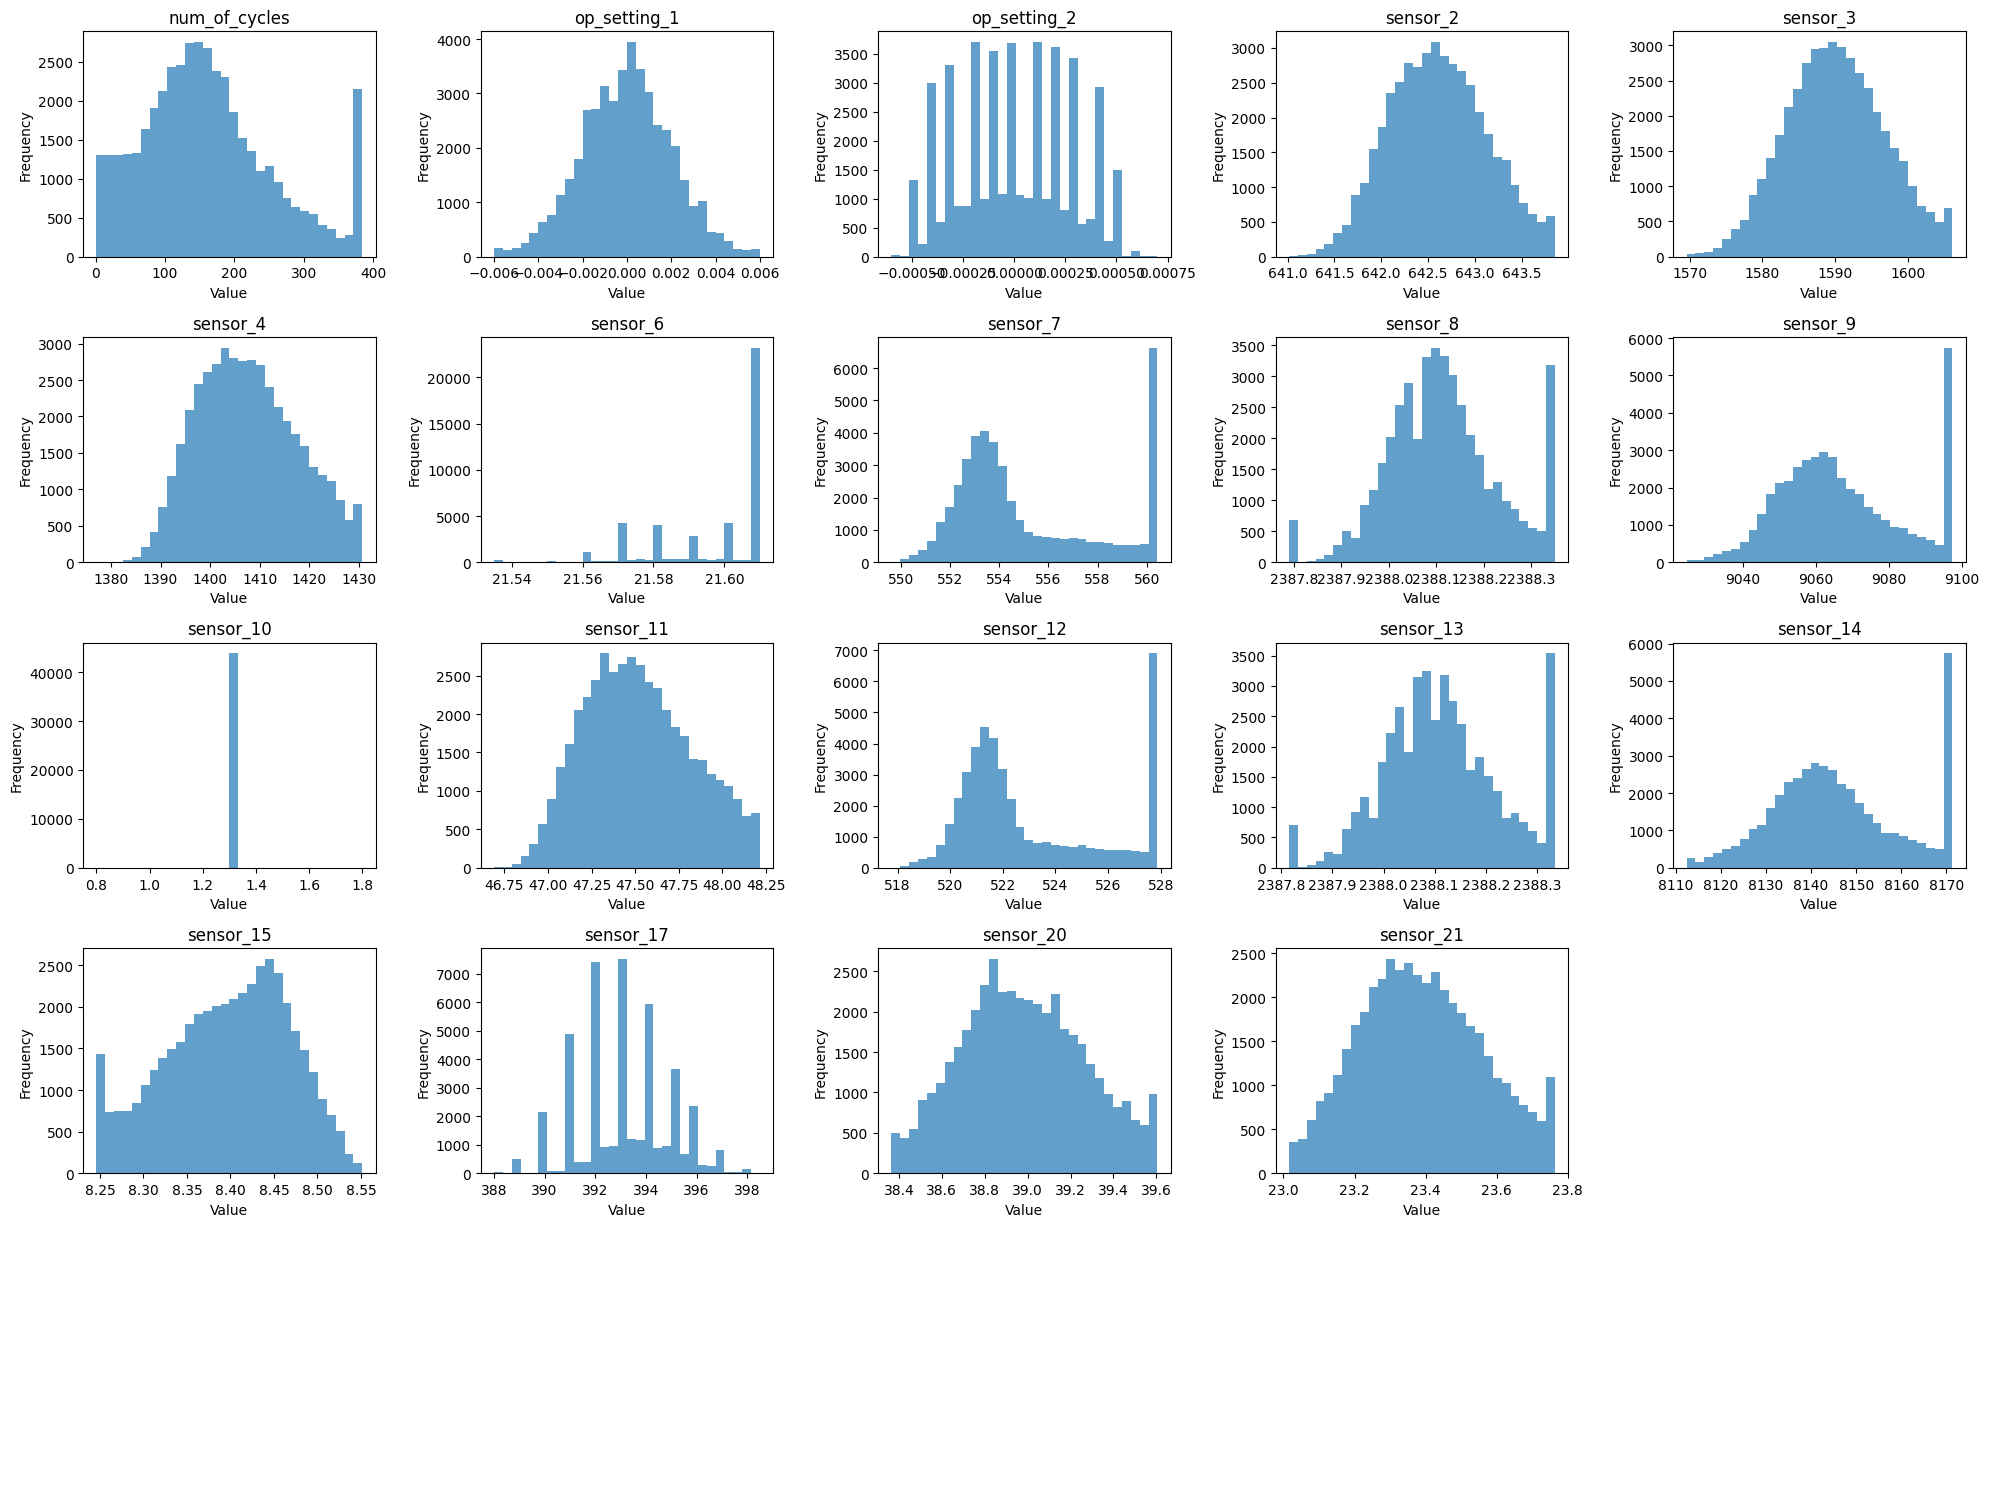

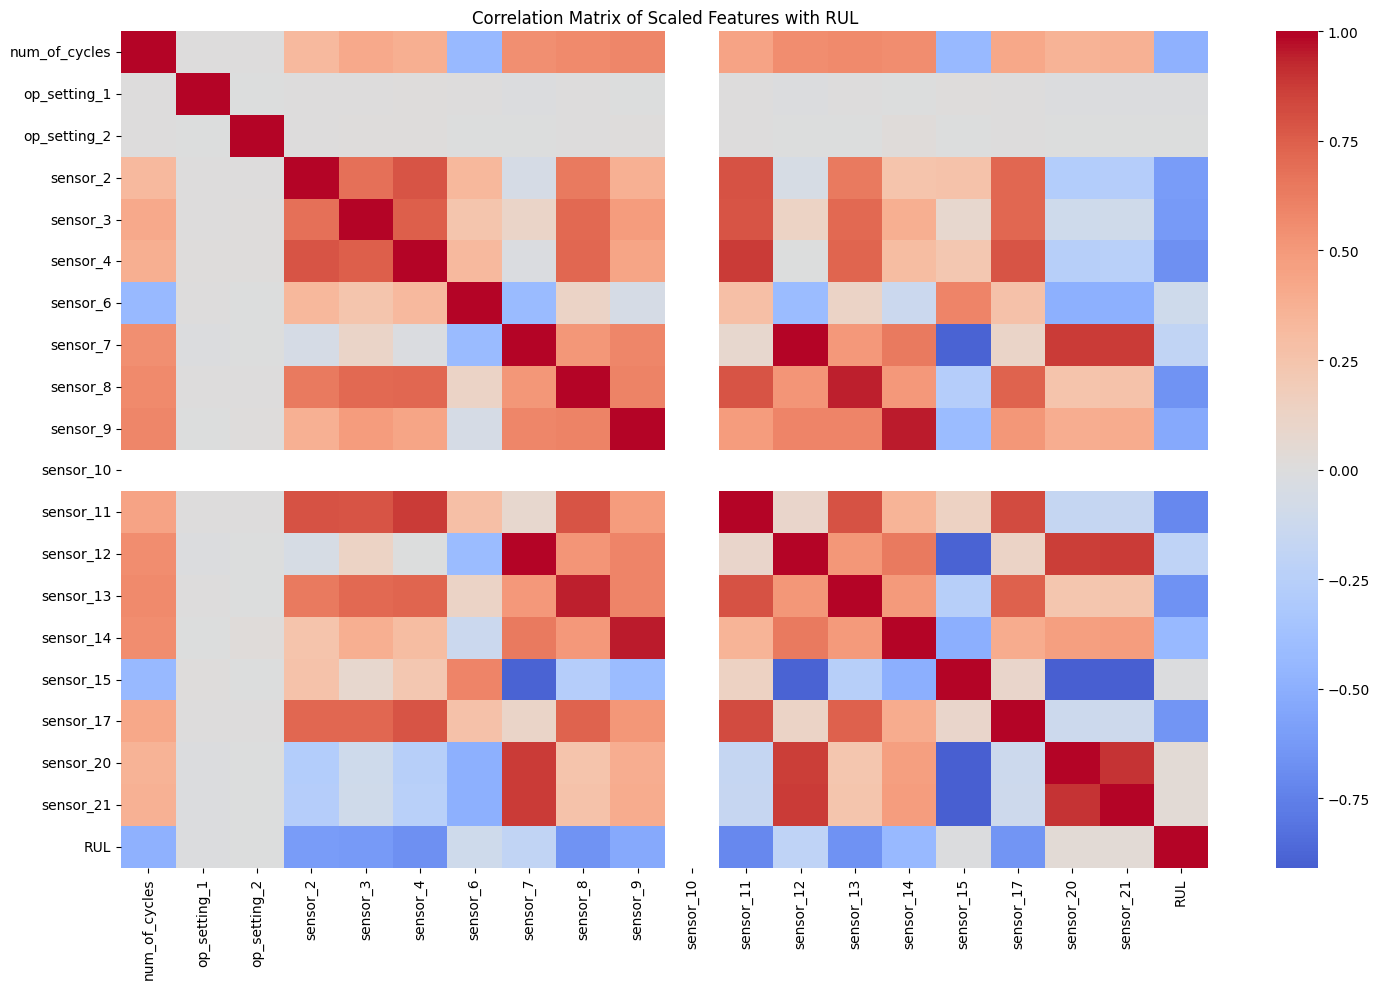

Visualization completed!


In [57]:
print("\n" + "="*50)
print("FINAL DATA VISUALIZATION")
print("="*50)

# Use scaled features from classification dataset for visualization
X_scaled_vis = X_scaled_df.copy()  # This is from feature scaling step

# Visualize scaled features (first 25 only)
fig, axes = plt.subplots(5, 5, figsize=(20, 15))
axes = axes.ravel()

for i in range(25):
    if i < len(X_scaled_vis.columns):
        axes[i].hist(X_scaled_vis.iloc[:, i], bins=30, alpha=0.7)
        axes[i].set_title(X_scaled_vis.columns[i])
        axes[i].set_xlabel('Value')
        axes[i].set_ylabel('Frequency')
    else:
        axes[i].axis('off')

plt.tight_layout()
plt.show()

# Correlation heatmap with RUL
if y_rul is not None:
    plt.figure(figsize=(15, 10))
    temp_df = X_scaled_vis.copy()
    temp_df['RUL'] = y_rul
    correlation_matrix = temp_df.corr()
    sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0)
    plt.title('Correlation Matrix of Scaled Features with RUL')
    plt.tight_layout()
    plt.show()

# Correlation heatmap with class (using encoded version)
if 'class_encoded' in df_balanced.columns:
    plt.figure(figsize=(15, 10))
    temp_df = X_scaled_vis.copy()
    temp_df['class_encoded'] = df_balanced['class_encoded'].values
    correlation_matrix = temp_df.corr()
    sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0)
    plt.title('Correlation Matrix of Scaled Features with Class (Encoded)')
    plt.tight_layout()
    plt.show()

print("Visualization completed!")
print("="*50)